# Phyloseq analysis

https://www.bioconductor.org/packages/release/bioc/html/phyloseq.html

Need to make a phyloseq object to run lefse \
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [1]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR"

In [ ]:
##created a new conda environment (not using r_env)
#conda create --prefix /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/phyloseq 
#conda activate /work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/.conda/envs/phyloseq
#conda install conda-forge::r-base==4.4.3 #lets try 4.4 rather than the newest 4.5.2
#conda install bioconda::bioconductor-phyloseq
#pip install jupyter
#conda install -c conda-forge r-irkernel
##then move out of terminal and choose R[conda env:.conda-phyloseq] kernel

In [1]:
#if (!require("BiocManager", quietly = TRUE))
#    install.packages("BiocManager")

#BiocManager::install("phyloseq")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.27), R 4.4.3 (2025-02-28)

Warning message:
“package(s) not installed when version(s) same as or greater than current; use
  `force = TRUE` to re-install: 'phyloseq'”
Installing package(s) 'BiocVersion'

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'Biostrings', 'data.table', 'GenomeInfoDb', 'igraph', 'IRanges',
  'rhdf5', 'rhdf5filters', 'vroom'



In [2]:
#install.packages('ecodist')

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
#install.packages('tidyverse') 

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [4]:
#install.packages("remotes")
#remotes::install_github("vegandevs/vegan")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done




Running `R CMD build`...



* checking for file ‘/tmp/RtmpQxzaw4/remotes1031ce27efb3a9/vegandevs-vegan-b2a4b98/DESCRIPTION’ ... OK
* preparing ‘vegan’:
* checking DESCRIPTION meta-information ... OK
* cleaning src
* installing the package to process help pages
* saving partial Rd database
* cleaning src
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* looking to see if a ‘data/datalist’ file should be added
* building ‘vegan_2.8-0.tar.gz’


In [6]:
#remotes::install_github("gavinsimpson/ggvegan")

ggrepel (NA -> 0.9.6) [CRAN]


Installing 1 packages: ggrepel

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Running `R CMD build`...



* checking for file ‘/tmp/RtmpQxzaw4/remotes1031ce35b4395f/gavinsimpson-ggvegan-cb025bc/DESCRIPTION’ ... OK
* preparing ‘ggvegan’:
* checking DESCRIPTION meta-information ... OK
* checking for LF line-endings in source and make files and shell scripts
* checking for empty or unneeded directories
* building ‘ggvegan_0.2.1.tar.gz’


In [44]:
if (!require("BiocManager", quietly = TRUE))
    install.packages("BiocManager")

BiocManager::install("DESeq2")

Bioconductor version '3.20' is out-of-date; the current release version '3.22'
  is available with R version '4.5'; see https://bioconductor.org/install

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    CRAN: https://cran.r-project.org

Bioconductor version 3.20 (BiocManager 1.30.27), R 4.4.3 (2025-02-28)

Installing package(s) 'DESeq2'

also installing the dependencies ‘formatR’, ‘abind’, ‘SparseArray’, ‘lambda.r’, ‘futile.options’, ‘S4Arrays’, ‘DelayedArray’, ‘futile.logger’, ‘snow’, ‘BH’, ‘GenomicRanges’, ‘SummarizedExperiment’, ‘BiocParallel’, ‘matrixStats’, ‘locfit’, ‘MatrixGenerics’, ‘RcppArmadillo’


Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Old packages: 'Biostrings', 'data.table', 'DBI', 'GenomeInfoDb', 'igraph',
  'IRanges', 'rhdf5', 'rhdf5filters', 'vroom'



In [47]:
install.packages("dplyr")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



#### ready to go!

In [48]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)
library(RColorBrewer)
library(DESeq2)
library(dplyr)

In [2]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/bracken_filtered/otu_table_species")

In [3]:
taxa = read.csv('otu_id_species.csv',header=TRUE)
head(taxa)

,taxonomy_id,name,taxonomy_lvl
,<int>,<chr>,<chr>
1,2066072,Bacterioplanoides sp.,S
2,588596,Rhizophagus irregularis,S
3,562,Escherichia coli,S
4,5722,Trichomonas vaginalis,S
5,1280,Staphylococcus aureus,S
6,2093777,Podospora bellae-mahoneyi,S


In [4]:
# remove taxa level col
taxa$taxonomy_lvl <- NULL 
# change taxa table names
colnames(taxa) <- c("otuid","species")

In [5]:
head(taxa)

,otuid,species
,<int>,<chr>
1,2066072,Bacterioplanoides sp.
2,588596,Rhizophagus irregularis
3,562,Escherichia coli
4,5722,Trichomonas vaginalis
5,1280,Staphylococcus aureus
6,2093777,Podospora bellae-mahoneyi


In [6]:
# make the index the otu ids
row.names(taxa) <- taxa$otuid
taxa$otuid <- NULL
head(taxa)

,species
,<chr>
2066072,Bacterioplanoides sp.
588596,Rhizophagus irregularis
562,Escherichia coli
5722,Trichomonas vaginalis
1280,Staphylococcus aureus
2093777,Podospora bellae-mahoneyi


In [7]:
str(taxa)

'data.frame':	13490 obs. of  1 variable:
 $ species: chr  "Bacterioplanoides sp." "Rhizophagus irregularis" "Escherichia coli" "Trichomonas vaginalis" ...


In [8]:
#convert to character matrix to create phyloseq objects 
taxonomy <- as.matrix(taxa)

# check structure
str(taxonomy)    

 chr [1:13490, 1] "Bacterioplanoides sp." "Rhizophagus irregularis" ...
 - attr(*, "dimnames")=List of 2
  ..$ : chr [1:13490] "2066072" "588596" "562" "5722" ...
  ..$ : chr "species"


In [9]:
#read in normalized otu table
otu = read.csv('otu_normtable_species.csv',header=TRUE)
head(otu)

,X,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,⋯,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31,X122021_Coralina_2021_Baya_025_MMEA_S22,X122021_Coralina_2021_Baya_027_PSTR4_S34,X122021_Coralina_2021_Baya_029_MMEA_S23,X122021_Coralina_2021_Baya_031_MMEA_S45,X122021_Coralina_2021_Baya_033_PSTR7_S35,X122021_Coralina_2021_Baya_035_PSTR_S32,X122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,58590.155,46974.0420,31054.6804,22114.965,18388.4556,9050.2324,4278.6221,2757.5733,1848.7994,⋯,54767.263,24032.7084,3176.6267,15737.9153,4016.541,2565.8136,59856.8157,62344.6598,71344.0886,782714.15
2,588596,19338.203,18978.8683,12952.0575,0.000,7778.9784,4770.0595,1743.2235,14339.3813,7506.5710,⋯,10475.605,23390.7559,9352.2398,9076.8691,14236.144,10366.6388,10688.0193,0.0000,9887.8743,330478.52
3,562,6052.054,6470.9139,6157.6466,8214.486,9979.1725,7097.0208,32990.8610,6506.2745,5586.4926,⋯,3389.796,8177.1041,10282.2391,7151.9700,10789.999,10573.4076,4169.6953,3958.4601,4240.1949,238546.68
4,5722,5190.238,5830.4340,4073.4853,3699.321,0.0000,3144.1428,1407.9461,4555.9907,2877.8901,⋯,7385.724,5883.5261,5109.7713,2954.4963,6916.057,5056.4385,5768.0133,5705.2229,5003.0752,252418.48
5,1280,3917.071,2747.8658,2009.6463,2908.389,2947.9470,3055.4564,1666.5261,2214.0516,1572.5932,⋯,3016.793,3297.0183,4346.9629,2247.2078,6393.193,3336.4975,3681.2118,3471.7998,3625.1597,86317.35
6,2093777,3794.999,280.9848,216.7708,0.000,395.4086,120.3601,104.0894,263.7679,182.6525,⋯,2755.942,149.5812,261.2357,155.1857,0.000,197.3703,339.9845,308.5079,603.2076,12535.40


In [10]:
# rename first col as otu
names(otu)[1] <- "otu"
head(otu)
dim(otu)

,otu,X072023_Carolina_2023_Baya_052_DCYL_S9,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X072023_Carolina_2023_Baya_057_SSID_S7,X072023_Carolina_2023_Baya_059_SSID_S8,X072023_Carolina_2023_Baya_061_SSID_S5,X072023_Carolina_2023_Baya_063_SSID_S6,X072023_Carolina_2023_Baya_065_DCYL_S1,X072023_Carolina_2023_Baya_066_DCYL_S2,⋯,X122021_Coralina_2021_Baya_021_SSID2_S36,X122021_Coralina_2021_Baya_023_MCAV_S31,X122021_Coralina_2021_Baya_025_MMEA_S22,X122021_Coralina_2021_Baya_027_PSTR4_S34,X122021_Coralina_2021_Baya_029_MMEA_S23,X122021_Coralina_2021_Baya_031_MMEA_S45,X122021_Coralina_2021_Baya_033_PSTR7_S35,X122021_Coralina_2021_Baya_035_PSTR_S32,X122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,58590.155,46974.0420,31054.6804,22114.965,18388.4556,9050.2324,4278.6221,2757.5733,1848.7994,⋯,54767.263,24032.7084,3176.6267,15737.9153,4016.541,2565.8136,59856.8157,62344.6598,71344.0886,782714.15
2,588596,19338.203,18978.8683,12952.0575,0.000,7778.9784,4770.0595,1743.2235,14339.3813,7506.5710,⋯,10475.605,23390.7559,9352.2398,9076.8691,14236.144,10366.6388,10688.0193,0.0000,9887.8743,330478.52
3,562,6052.054,6470.9139,6157.6466,8214.486,9979.1725,7097.0208,32990.8610,6506.2745,5586.4926,⋯,3389.796,8177.1041,10282.2391,7151.9700,10789.999,10573.4076,4169.6953,3958.4601,4240.1949,238546.68
4,5722,5190.238,5830.4340,4073.4853,3699.321,0.0000,3144.1428,1407.9461,4555.9907,2877.8901,⋯,7385.724,5883.5261,5109.7713,2954.4963,6916.057,5056.4385,5768.0133,5705.2229,5003.0752,252418.48
5,1280,3917.071,2747.8658,2009.6463,2908.389,2947.9470,3055.4564,1666.5261,2214.0516,1572.5932,⋯,3016.793,3297.0183,4346.9629,2247.2078,6393.193,3336.4975,3681.2118,3471.7998,3625.1597,86317.35
6,2093777,3794.999,280.9848,216.7708,0.000,395.4086,120.3601,104.0894,263.7679,182.6525,⋯,2755.942,149.5812,261.2357,155.1857,0.000,197.3703,339.9845,308.5079,603.2076,12535.40


[1] 13491    30

In [11]:
#remove X's from headers
names(otu) <- sub("^X", "", names(otu))
otu_table=as.data.frame(otu)
head(otu_table)

,otu,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,⋯,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,58590.155,46974.0420,31054.6804,22114.965,18388.4556,9050.2324,4278.6221,2757.5733,1848.7994,⋯,54767.263,24032.7084,3176.6267,15737.9153,4016.541,2565.8136,59856.8157,62344.6598,71344.0886,782714.15
2,588596,19338.203,18978.8683,12952.0575,0.000,7778.9784,4770.0595,1743.2235,14339.3813,7506.5710,⋯,10475.605,23390.7559,9352.2398,9076.8691,14236.144,10366.6388,10688.0193,0.0000,9887.8743,330478.52
3,562,6052.054,6470.9139,6157.6466,8214.486,9979.1725,7097.0208,32990.8610,6506.2745,5586.4926,⋯,3389.796,8177.1041,10282.2391,7151.9700,10789.999,10573.4076,4169.6953,3958.4601,4240.1949,238546.68
4,5722,5190.238,5830.4340,4073.4853,3699.321,0.0000,3144.1428,1407.9461,4555.9907,2877.8901,⋯,7385.724,5883.5261,5109.7713,2954.4963,6916.057,5056.4385,5768.0133,5705.2229,5003.0752,252418.48
5,1280,3917.071,2747.8658,2009.6463,2908.389,2947.9470,3055.4564,1666.5261,2214.0516,1572.5932,⋯,3016.793,3297.0183,4346.9629,2247.2078,6393.193,3336.4975,3681.2118,3471.7998,3625.1597,86317.35
6,2093777,3794.999,280.9848,216.7708,0.000,395.4086,120.3601,104.0894,263.7679,182.6525,⋯,2755.942,149.5812,261.2357,155.1857,0.000,197.3703,339.9845,308.5079,603.2076,12535.40


In [12]:
# make the index the otus
row.names(otu_table) <- otu_table$otu
otu_table$otu <- NULL
head(otu_table)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,⋯,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33,Sum
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,58590.155,46974.0420,31054.6804,22114.965,18388.4556,9050.2324,4278.6221,2757.5733,1848.7994,1868.755,⋯,54767.263,24032.7084,3176.6267,15737.9153,4016.541,2565.8136,59856.8157,62344.6598,71344.0886,782714.15
588596,19338.203,18978.8683,12952.0575,0.000,7778.9784,4770.0595,1743.2235,14339.3813,7506.5710,8633.338,⋯,10475.605,23390.7559,9352.2398,9076.8691,14236.144,10366.6388,10688.0193,0.0000,9887.8743,330478.52
562,6052.054,6470.9139,6157.6466,8214.486,9979.1725,7097.0208,32990.8610,6506.2745,5586.4926,15289.811,⋯,3389.796,8177.1041,10282.2391,7151.9700,10789.999,10573.4076,4169.6953,3958.4601,4240.1949,238546.68
5722,5190.238,5830.4340,4073.4853,3699.321,0.0000,3144.1428,1407.9461,4555.9907,2877.8901,3629.400,⋯,7385.724,5883.5261,5109.7713,2954.4963,6916.057,5056.4385,5768.0133,5705.2229,5003.0752,252418.48
1280,3917.071,2747.8658,2009.6463,2908.389,2947.9470,3055.4564,1666.5261,2214.0516,1572.5932,2378.415,⋯,3016.793,3297.0183,4346.9629,2247.2078,6393.193,3336.4975,3681.2118,3471.7998,3625.1597,86317.35
2093777,3794.999,280.9848,216.7708,0.000,395.4086,120.3601,104.0894,263.7679,182.6525,0.000,⋯,2755.942,149.5812,261.2357,155.1857,0.000,197.3703,339.9845,308.5079,603.2076,12535.40


In [13]:
#remove Sum column
otu_table$Sum <- NULL
head(otu_table)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,58590.155,46974.0420,31054.6804,22114.965,18388.4556,9050.2324,4278.6221,2757.5733,1848.7994,1868.755,⋯,414.4389,54767.263,24032.7084,3176.6267,15737.9153,4016.541,2565.8136,59856.8157,62344.6598,71344.0886
588596,19338.203,18978.8683,12952.0575,0.000,7778.9784,4770.0595,1743.2235,14339.3813,7506.5710,8633.338,⋯,2418.0179,10475.605,23390.7559,9352.2398,9076.8691,14236.144,10366.6388,10688.0193,0.0000,9887.8743
562,6052.054,6470.9139,6157.6466,8214.486,9979.1725,7097.0208,32990.8610,6506.2745,5586.4926,15289.811,⋯,1836.1566,3389.796,8177.1041,10282.2391,7151.9700,10789.999,10573.4076,4169.6953,3958.4601,4240.1949
5722,5190.238,5830.4340,4073.4853,3699.321,0.0000,3144.1428,1407.9461,4555.9907,2877.8901,3629.400,⋯,21284.5960,7385.724,5883.5261,5109.7713,2954.4963,6916.057,5056.4385,5768.0133,5705.2229,5003.0752
1280,3917.071,2747.8658,2009.6463,2908.389,2947.9470,3055.4564,1666.5261,2214.0516,1572.5932,2378.415,⋯,1698.9252,3016.793,3297.0183,4346.9629,2247.2078,6393.193,3336.4975,3681.2118,3471.7998,3625.1597
2093777,3794.999,280.9848,216.7708,0.000,395.4086,120.3601,104.0894,263.7679,182.6525,0.000,⋯,0.0000,2755.942,149.5812,261.2357,155.1857,0.000,197.3703,339.9845,308.5079,603.2076


In [14]:
# sort by most abundant OTUs
otus_sorted <- otu_table[order(rowSums(otu_table), decreasing = TRUE), ]
head(otus_sorted)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Total_reads,2326483.0000,242006.0000,442864.00000,160570.0000,255432.0000,473579.0000,912677.0000,125110.0000,224470.000,64749.000,⋯,364348.0000,793558.0000,160448.000,95699.000,670165.000,42076.000,106399.000,255894.000,230140.000,169096.000
2066072,58590.1552,46974.0420,31054.68044,22114.9654,18388.4556,9050.2324,4278.6221,2757.5733,1848.799,1868.755,⋯,414.4389,54767.2634,24032.708,3176.627,15737.915,4016.541,2565.814,59856.816,62344.660,71344.089
588596,19338.2028,18978.8683,12952.05752,0.0000,7778.9784,4770.0595,1743.2235,14339.3813,7506.571,8633.338,⋯,2418.0179,10475.6048,23390.756,9352.240,9076.869,14236.144,10366.639,10688.019,0.000,9887.874
2057741,559.2132,132.2281,83.54709,205.5178,187.9169,238.6086,473.3328,167.8523,0.000,11552.302,⋯,83280.2705,981.6548,3253.391,13615.607,1047.503,19417.245,39098.112,2164.959,12179.543,4701.471
5722,5190.2378,5830.4340,4073.48531,3699.3212,0.0000,3144.1428,1407.9461,4555.9907,2877.890,3629.400,⋯,21284.5960,7385.7235,5883.526,5109.771,2954.496,6916.057,5056.439,5768.013,5705.223,5003.075
562,6052.0537,6470.9139,6157.64659,8214.4859,9979.1725,7097.0208,32990.8610,6506.2745,5586.493,15289.811,⋯,1836.1566,3389.7963,8177.104,10282.239,7151.970,10789.999,10573.408,4169.695,3958.460,4240.195


In [15]:
#remove total reads row
otus_sorted <- otus_sorted[-1, ]
head(otus_sorted)
dim (otus_sorted)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,58590.1552,46974.0420,31054.68044,22114.9654,18388.4556,9050.2324,4278.6221,2757.5733,1848.799,1868.755,⋯,414.4389,54767.2634,24032.708,3176.627,15737.915,4016.541,2565.814,59856.816,62344.660,71344.089
588596,19338.2028,18978.8683,12952.05752,0.0000,7778.9784,4770.0595,1743.2235,14339.3813,7506.571,8633.338,⋯,2418.0179,10475.6048,23390.756,9352.240,9076.869,14236.144,10366.639,10688.019,0.000,9887.874
2057741,559.2132,132.2281,83.54709,205.5178,187.9169,238.6086,473.3328,167.8523,0.000,11552.302,⋯,83280.2705,981.6548,3253.391,13615.607,1047.503,19417.245,39098.112,2164.959,12179.543,4701.471
5722,5190.2378,5830.4340,4073.48531,3699.3212,0.0000,3144.1428,1407.9461,4555.9907,2877.890,3629.400,⋯,21284.5960,7385.7235,5883.526,5109.771,2954.496,6916.057,5056.439,5768.013,5705.223,5003.075
562,6052.0537,6470.9139,6157.64659,8214.4859,9979.1725,7097.0208,32990.8610,6506.2745,5586.493,15289.811,⋯,1836.1566,3389.7963,8177.104,10282.239,7151.970,10789.999,10573.408,4169.695,3958.460,4240.195
1396,3184.2055,3251.9855,3206.40197,5131.7183,4674.4339,2947.7658,1207.4370,12596.9147,7484.296,5853.372,⋯,1473.8656,3769.1007,4711.807,10104.599,4592.899,12524.955,6212.464,4107.169,4214.826,4133.747


[1] 13490    28

In [16]:
# Convert to matrix
otus=as.matrix(otus_sorted)
head(otus)

,072023_Carolina_2023_Baya_052_DCYL_S9,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,072023_Carolina_2023_Baya_057_SSID_S7,072023_Carolina_2023_Baya_059_SSID_S8,072023_Carolina_2023_Baya_061_SSID_S5,072023_Carolina_2023_Baya_063_SSID_S6,072023_Carolina_2023_Baya_065_DCYL_S1,072023_Carolina_2023_Baya_066_DCYL_S2,122021_Coralina_2021_Baya_001_DCYL_S24,⋯,122021_Coralina_2021_Baya_019_SSID1_S46,122021_Coralina_2021_Baya_021_SSID2_S36,122021_Coralina_2021_Baya_023_MCAV_S31,122021_Coralina_2021_Baya_025_MMEA_S22,122021_Coralina_2021_Baya_027_PSTR4_S34,122021_Coralina_2021_Baya_029_MMEA_S23,122021_Coralina_2021_Baya_031_MMEA_S45,122021_Coralina_2021_Baya_033_PSTR7_S35,122021_Coralina_2021_Baya_035_PSTR_S32,122021_Coralina_2021_Baya_037_PSTR_S33
2066072,58590.1552,46974.0420,31054.68044,22114.9654,18388.4556,9050.2324,4278.6221,2757.5733,1848.799,1868.755,⋯,414.4389,54767.2634,24032.708,3176.627,15737.915,4016.541,2565.814,59856.816,62344.660,71344.089
588596,19338.2028,18978.8683,12952.05752,0.0000,7778.9784,4770.0595,1743.2235,14339.3813,7506.571,8633.338,⋯,2418.0179,10475.6048,23390.756,9352.240,9076.869,14236.144,10366.639,10688.019,0.000,9887.874
2057741,559.2132,132.2281,83.54709,205.5178,187.9169,238.6086,473.3328,167.8523,0.000,11552.302,⋯,83280.2705,981.6548,3253.391,13615.607,1047.503,19417.245,39098.112,2164.959,12179.543,4701.471
5722,5190.2378,5830.4340,4073.48531,3699.3212,0.0000,3144.1428,1407.9461,4555.9907,2877.890,3629.400,⋯,21284.5960,7385.7235,5883.526,5109.771,2954.496,6916.057,5056.439,5768.013,5705.223,5003.075
562,6052.0537,6470.9139,6157.64659,8214.4859,9979.1725,7097.0208,32990.8610,6506.2745,5586.493,15289.811,⋯,1836.1566,3389.7963,8177.104,10282.239,7151.970,10789.999,10573.408,4169.695,3958.460,4240.195
1396,3184.2055,3251.9855,3206.40197,5131.7183,4674.4339,2947.7658,1207.4370,12596.9147,7484.296,5853.372,⋯,1473.8656,3769.1007,4711.807,10104.599,4592.899,12524.955,6212.464,4107.169,4214.826,4133.747


In [17]:
getwd()

[1] "/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/bracken_filtered/otu_table_species"

In [18]:
#read in metadata
metadata=read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/bracken_filtered/otu_table_species/DR_metadata_all.csv', header=TRUE)
head(metadata)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_052_DCYL_S9,2023,DCYL,DM,DCYL-5,disease
2,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
3,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
4,072023_Carolina_2023_Baya_057_SSID_S7,2023,SSID,DT,SSID-2,disease
5,072023_Carolina_2023_Baya_059_SSID_S8,2023,SSID,DM,SSID-2,disease
6,072023_Carolina_2023_Baya_061_SSID_S5,2023,SSID,DT,SSID-1,disease


In [19]:
# index the SampleIDs
row.names(metadata) <- metadata$SampleID
metadata$SampleID <- NULL
head(metadata)

,Year,Species,Sample_type,Tag_num,SCTLD_status
,<int>,<chr>,<chr>,<chr>,<chr>
072023_Carolina_2023_Baya_052_DCYL_S9,2023,DCYL,DM,DCYL-5,disease
072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
072023_Carolina_2023_Baya_057_SSID_S7,2023,SSID,DT,SSID-2,disease
072023_Carolina_2023_Baya_059_SSID_S8,2023,SSID,DM,SSID-2,disease
072023_Carolina_2023_Baya_061_SSID_S5,2023,SSID,DT,SSID-1,disease


In [20]:
# classify phyloseq objects 
OTU=otu_table((otus), taxa_are_rows = TRUE)

In [21]:
TAX=tax_table(taxonomy)

In [22]:
SAMP=sample_data(metadata)

In [23]:
# Create phyloseq object
DR_all = phyloseq(OTU, SAMP, TAX)
DR_all

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13490 taxa and 28 samples ]
sample_data() Sample Data:       [ 28 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 13490 taxa by 1 taxonomic ranks ]

In [24]:
DR_all.ord <- ordinate(DR_all, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1017684 
Run 1 stress 0.1193168 
Run 2 stress 0.1152102 
Run 3 stress 0.121155 
Run 4 stress 0.101423 
... New best solution
... Procrustes: rmse 0.01588011  max resid 0.06990044 
Run 5 stress 0.1126698 
Run 6 stress 0.11267 
Run 7 stress 0.1067468 
Run 8 stress 0.1014229 
... New best solution
... Procrustes: rmse 0.0001835524  max resid 0.0008068474 
... Similar to previous best
Run 9 stress 0.1061919 
Run 10 stress 0.1144617 
Run 11 stress 0.1181693 
Run 12 stress 0.1126044 
Run 13 stress 0.1081485 
Run 14 stress 0.1086597 
Run 15 stress 0.1198373 
Run 16 stress 0.1146683 
Run 17 stress 0.11365 
Run 18 stress 0.1128897 
Run 19 stress 0.1126045 
Run 20 stress 0.1125358 
*** Best solution repeated 1 times


In [25]:
options(repr.plot.width=20, repr.plot.height=15)

In [26]:
library(RColorBrewer)

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


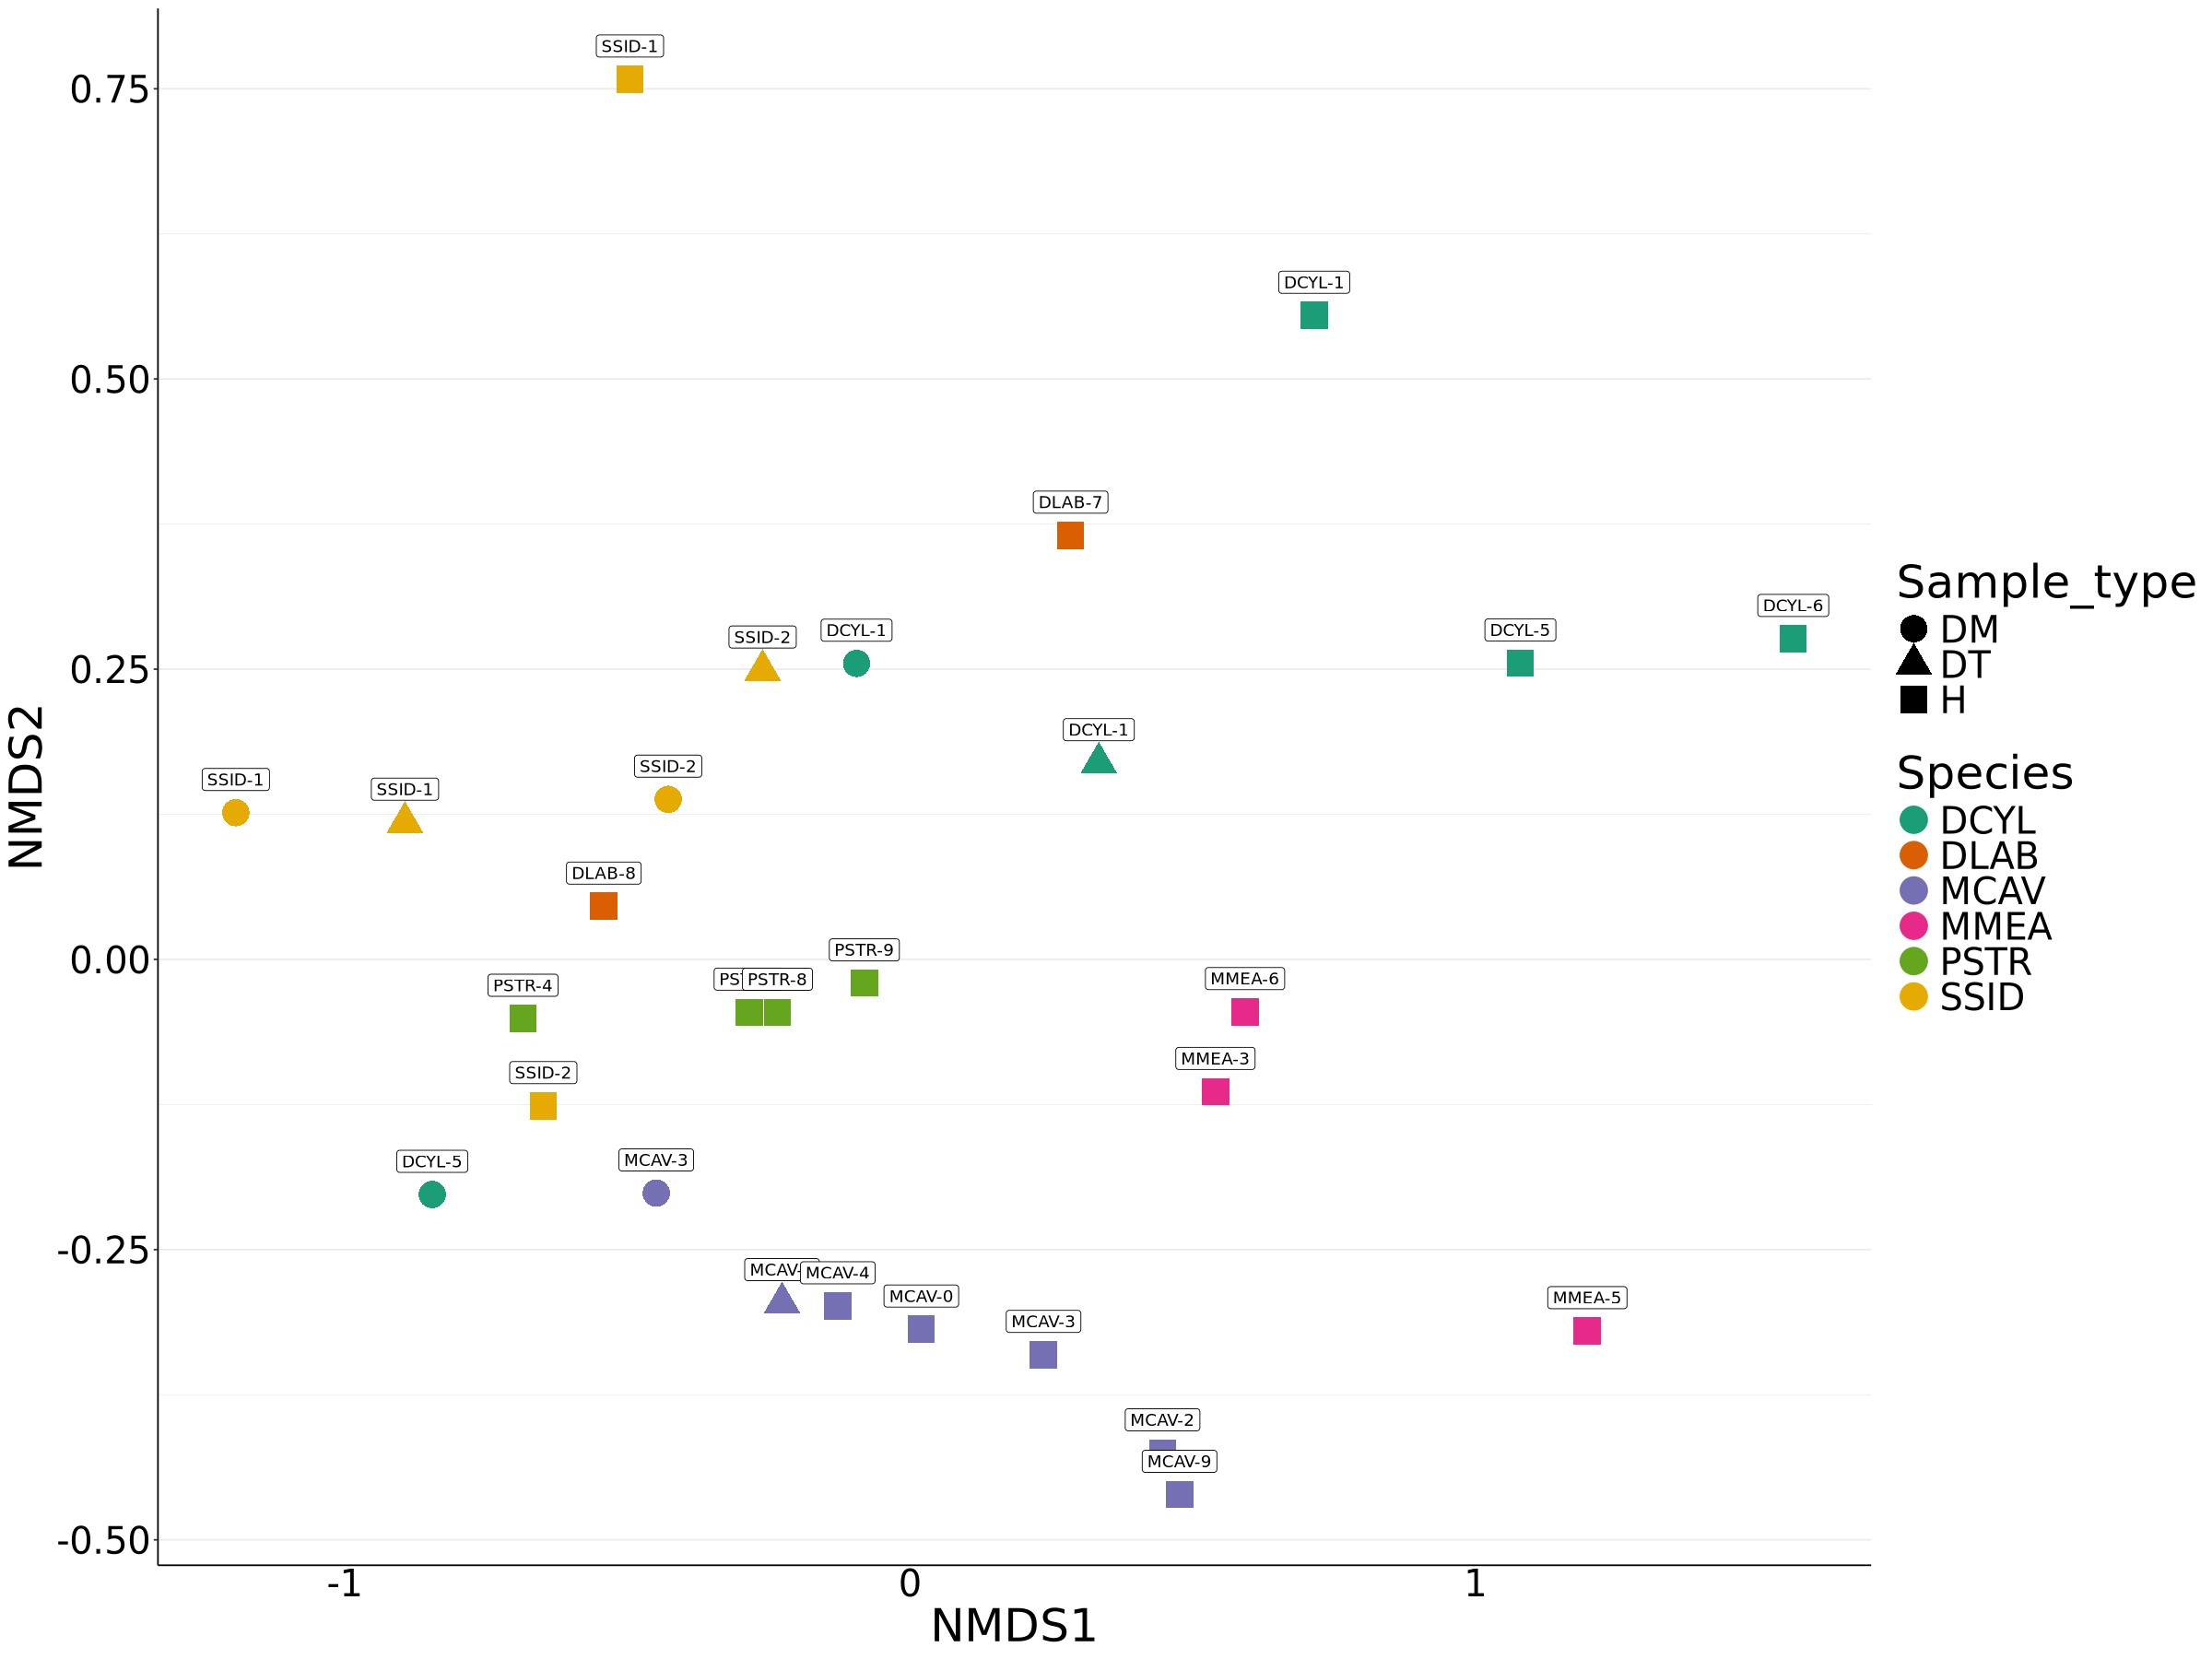

In [27]:
# visualize ordination plot

DR_all_plot <- plot_ordination(DR_all, DR_all.ord, type="Samples", color="Species", shape="Sample_type")+
geom_point(size=8) + scale_color_brewer(palette = "Dark2")+
geom_label(aes(label = SAMP$Tag_num), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 30))
DR_all_plot

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


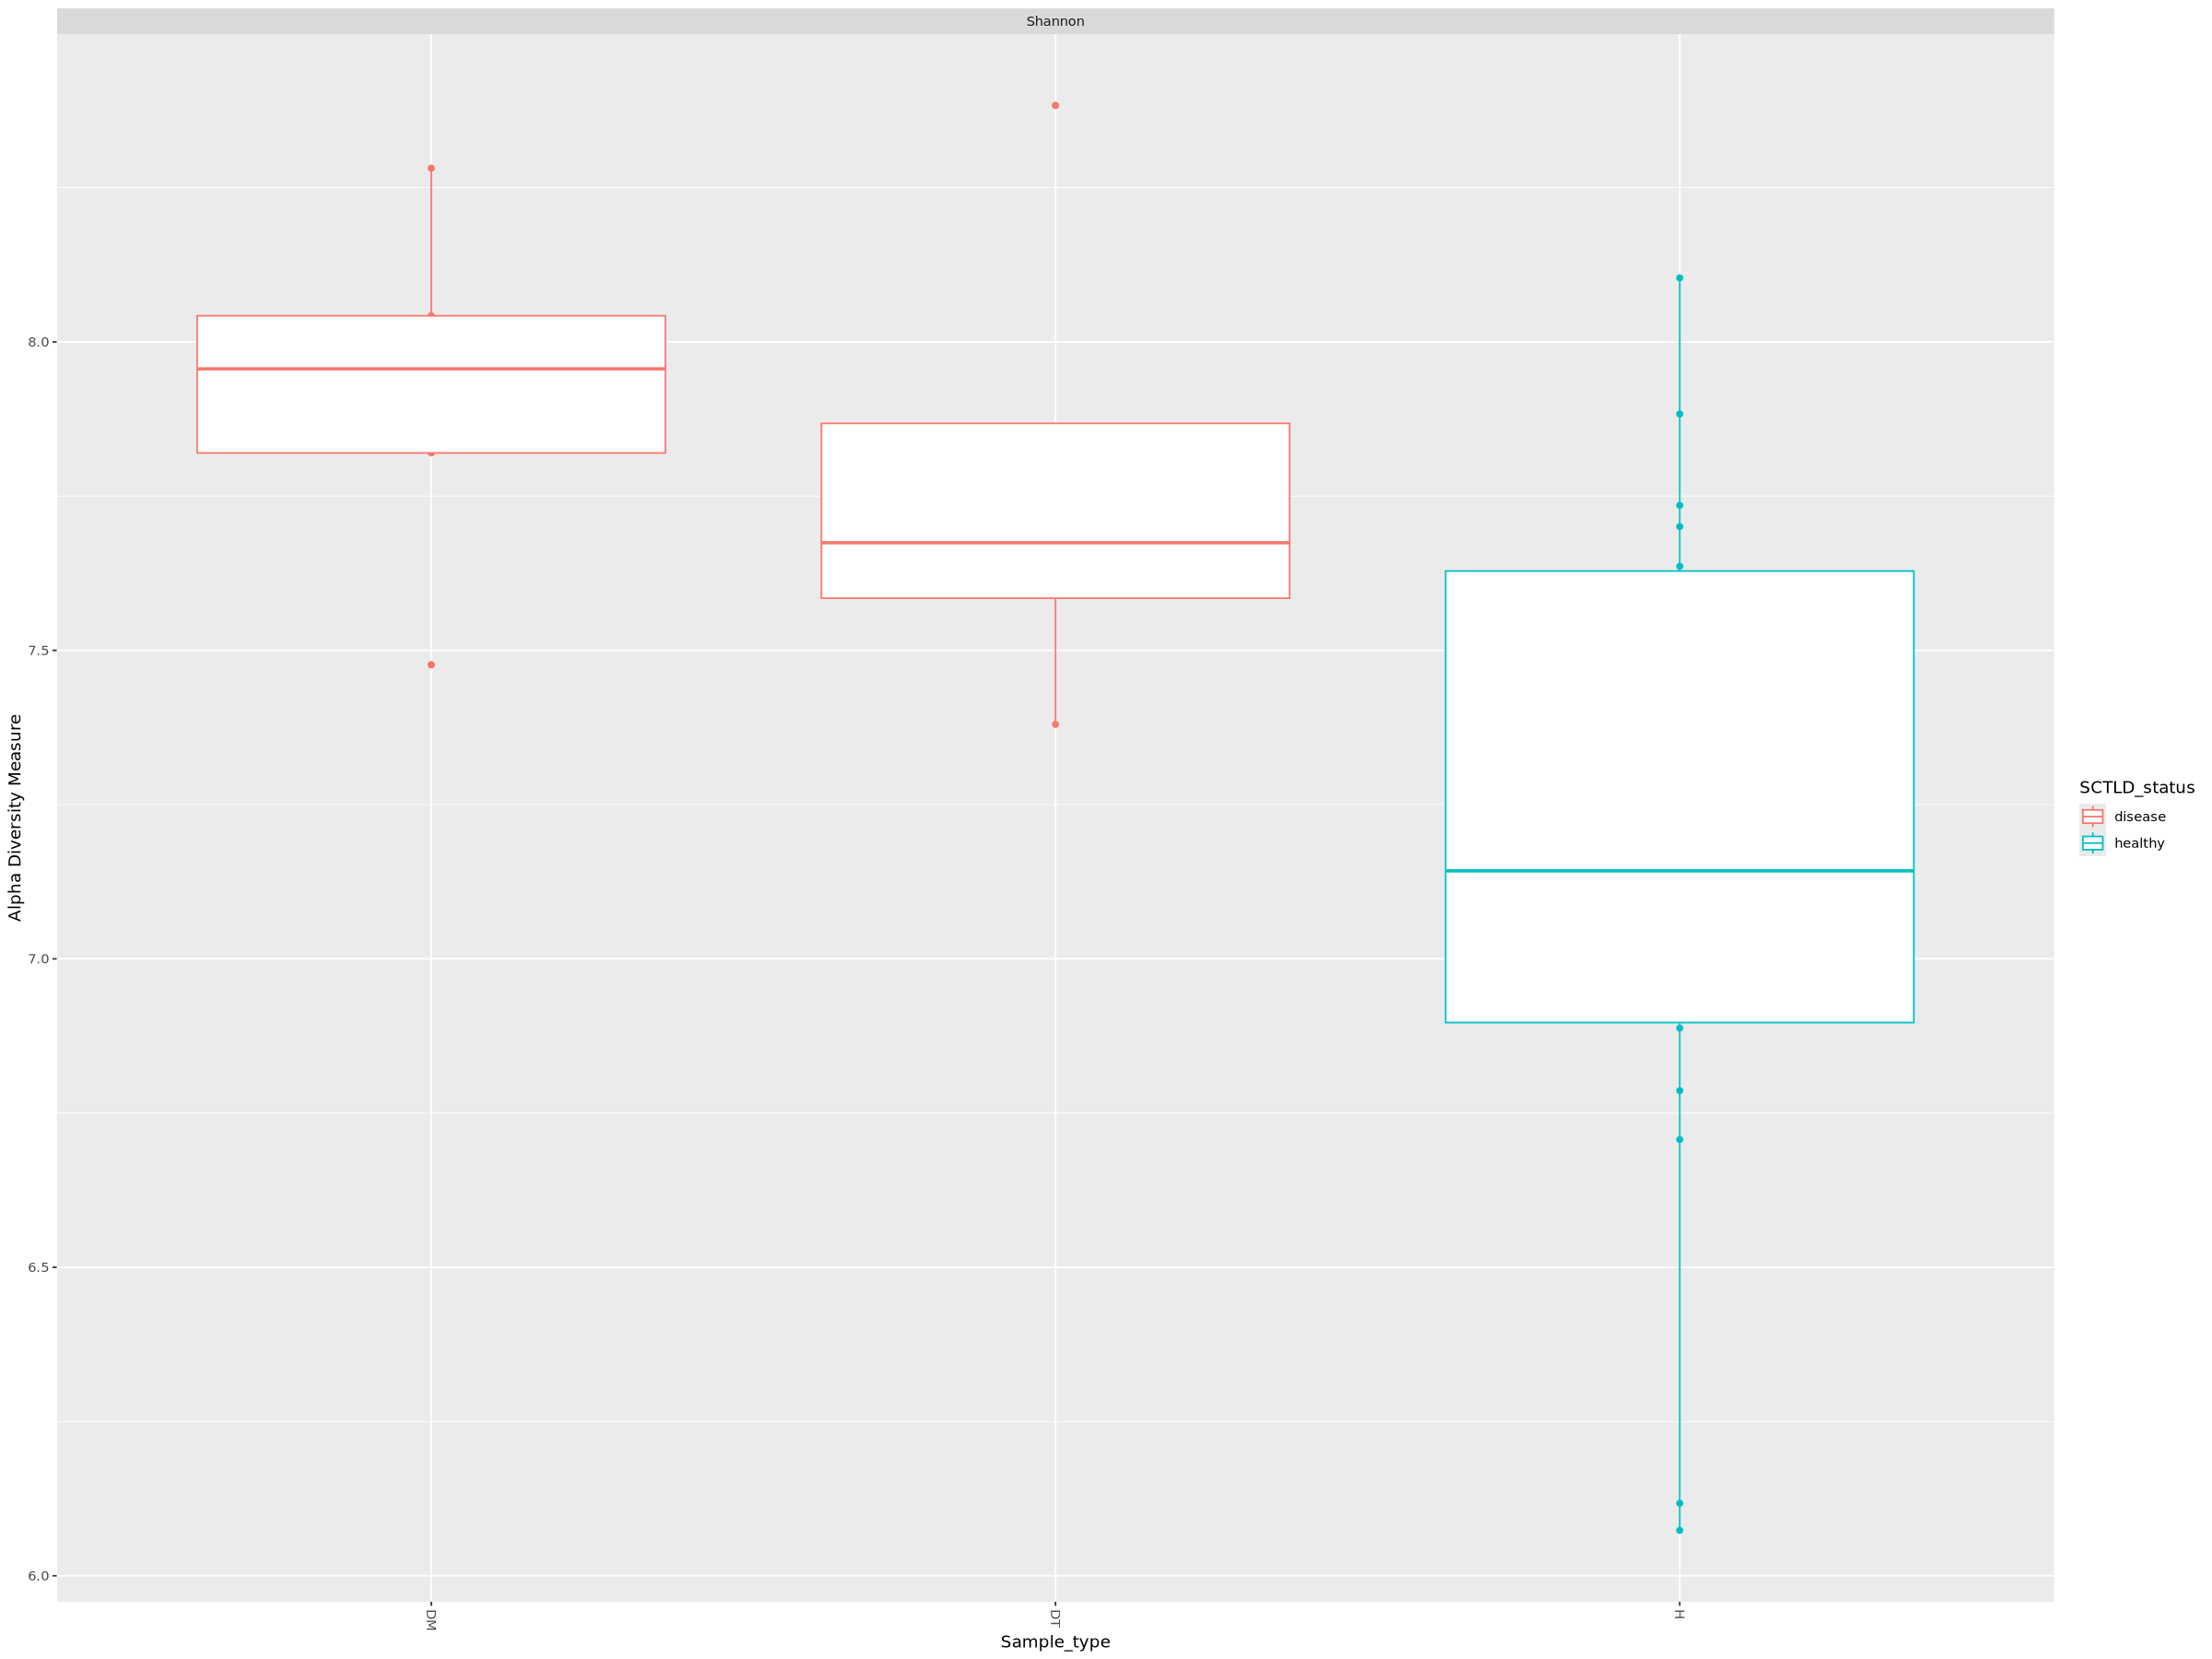

In [28]:
plot_richness(DR_all, x="Sample_type", color="SCTLD_status", measures=c("Shannon")) + geom_boxplot()

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


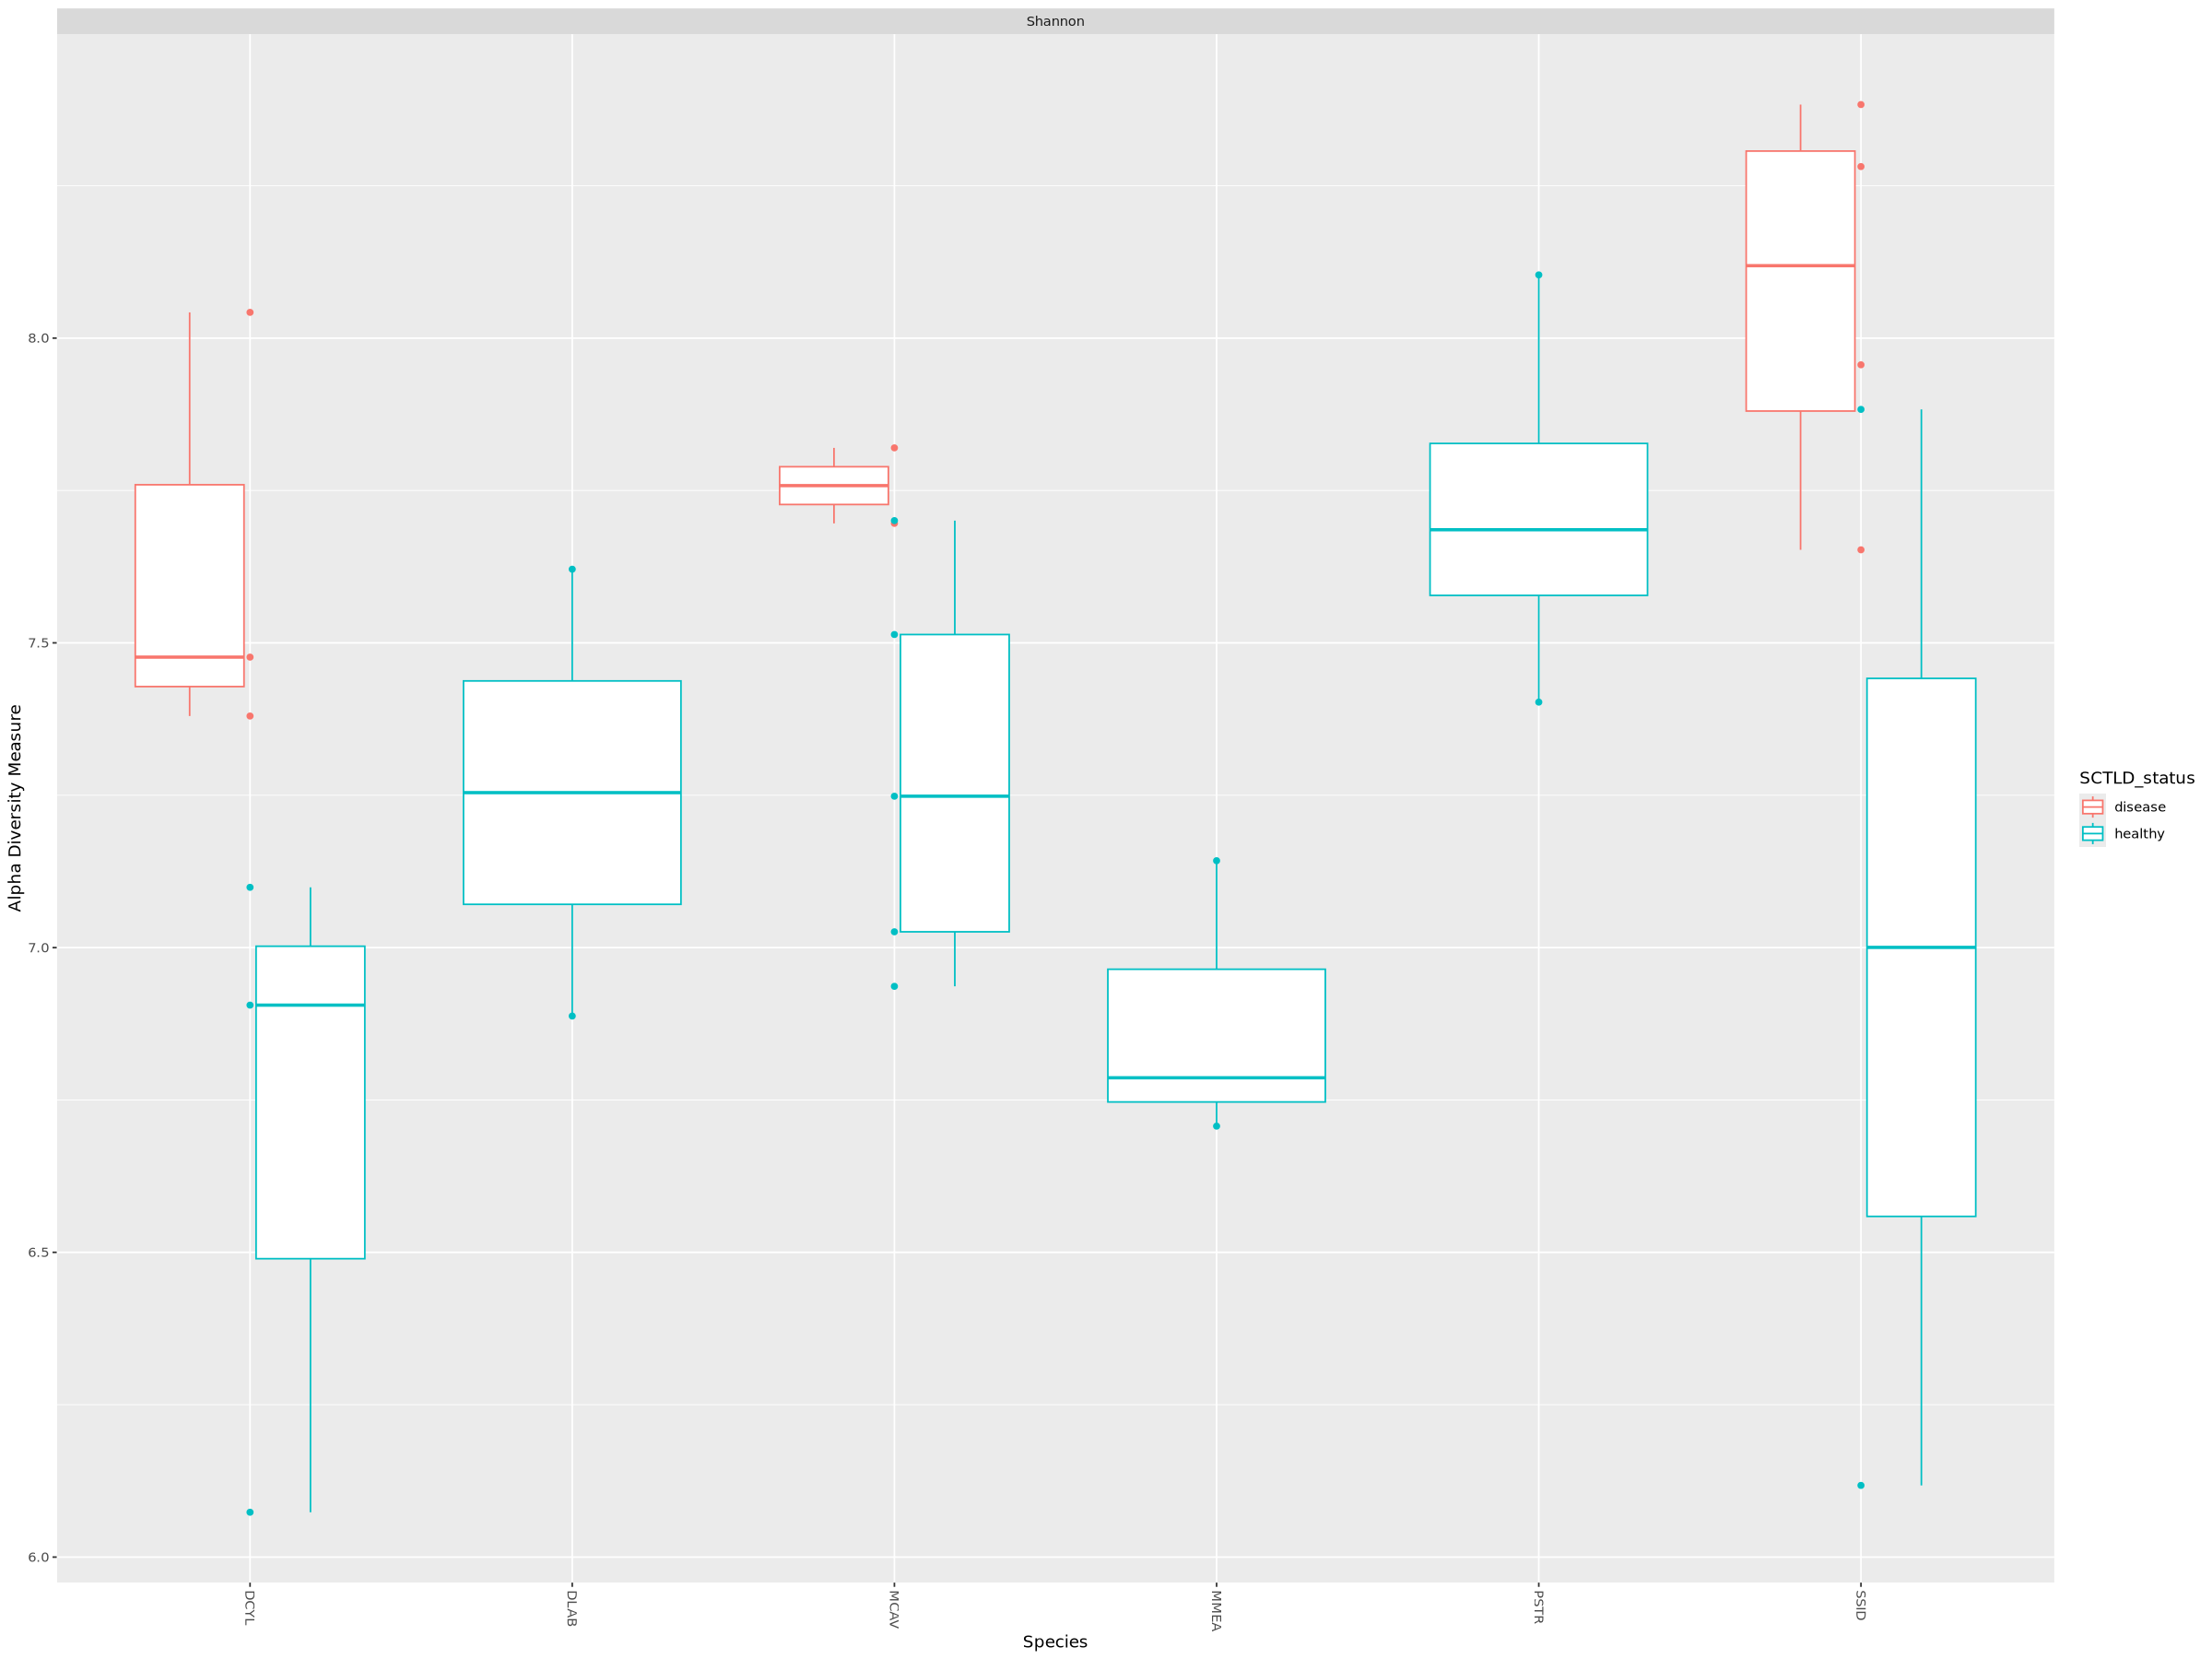

In [29]:
plot_richness(DR_all, x="Species", color="SCTLD_status", measures=c("Shannon")) + geom_boxplot()

In [33]:
##not working yet, kernel keeps quitting##
# Calculate the Bray-Curtis distance matrix
bray_dist_all <- phyloseq::distance(DR_all, method = "bray")

In [ ]:
#havne't run this yet
# adonis analysis 
sampledf <- data.frame(sample_data(DR_all))
#sample_data_df <- as(sample_data(DR_all), "data.frame")
adonis_result <- adonis2(bray_dist_all ~ Species * Sample_type, data = sampledf)
adonis_result

#### DESeq2 on DR_all just to see

In [76]:
#run DESeq2 on mcav
ds_all = phyloseq_to_deseq2(DR_all, ~ SCTLD_status)
ds_all = DESeq(ds_all, test="Wald", fitType="parametric")
res = results(ds_all, cooksCutoff = FALSE)
alpha = 0.0001
sigtab_a = res[which(res$padj < alpha), ]
sigtab_all = cbind(as(sigtab_a, "data.frame"), as(tax_table(DR_all)[rownames(sigtab_a), ], "matrix"))
res
head(sigtab_all)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 5005 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): SCTLD status healthy vs disease 
Wald test p-value: SCTLD status healthy vs disease 
DataFrame with 13490 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat      pvalue        padj
        <numeric>      <numeric> <numeric>  <numeric>   <numeric>   <numeric>
2066072  27510.96      0.2432014  0.767486  0.3168805 7.51334e-01 9.86754e-01
588596   11014.12      0.0686721  0.812439  0.0845258 9.32638e-01 9.96978e-01
2057741   7776.48      4.9156148  0.814443  6.0355540 1.58418e-09 7.24129e-08
5722      4580.32      0.2376247  0.586151  0.4053987 6.85184e-01 9.80589e-01
562       7338.41     -0.0981439  0.375013 -0.2617079 7.93547e-01 9.87316e-01
...           ...            ...       ...        ...         ...         ...
3050268  0.148142       -1.69682   3.19237  -0.531523    0.595057          NA
3048237  0.148142       -1.69682   3.19237  -0.531523    0.595057          NA
3429219  0.148142       -1.69682   3.19237  -0.531523    0.595057      

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2057741,7776.47694,4.915615,0.814443,6.035554,1.584183e-09,7.241292e-08,Bradyrhizobium sp. SK17
3240067,26.73427,22.357269,3.163498,7.067262,1.580205e-12,7.870466e-11,Streptomyces sp. CA-253872
2961995,219.74465,-28.405740,2.768778,-10.259306,1.074767e-24,3.782820e-21,Marinobacter metalliresistant
3369658,234.91109,-12.049106,1.461728,-8.243056,1.678665e-16,1.325460e-14,Marinobacter sp. W-8
3158171,215.80346,-11.926663,1.936508,-6.158850,7.327492e-10,3.363956e-08,Marinobacter sp. RI1
783,13.39648,21.398157,3.163944,6.763127,1.350450e-11,6.541012e-10,Rickettsia rickettsii


In [77]:
# sort by most significant 
sorted_sigtab_all <- sigtab_all %>%
  arrange(padj)
sorted_sigtab_all

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2903826,82.74919,-27.06343,2.386922,-11.338211,8.486180e-30,8.960558e-26,Streptomyces sp. NBC_01324
2861775,56.99167,-26.55816,2.364958,-11.229866,2.909193e-29,1.535909e-25,Pseudomonas sp. YeP6b
2961995,219.74465,-28.40574,2.768778,-10.259306,1.074767e-24,3.782820e-21,Marinobacter metalliresistant
1926,91.38790,-27.20426,2.670125,-10.188383,2.234491e-24,5.898497e-21,Streptomyces reticuli
2860286,80.39328,-27.01944,2.685566,-10.060985,8.217239e-24,1.735317e-20,Achromobacter sp. ES-001
2979870,51.46594,-26.40580,2.666322,-9.903454,4.021398e-23,7.076990e-20,Aminobacter sp. NyZ550
2602067,49.38830,-26.35993,2.671177,-9.868284,5.713349e-23,8.618179e-20,Octadecabacter sp. SW4
2560029,34.60491,-25.83427,2.634033,-9.807876,1.041369e-22,1.221758e-19,Aeromonas sp. 2692-1
1263728,48.97731,-26.34226,2.684365,-9.813220,9.876604e-23,1.221758e-19,Paracoccus sp. TOH


### let's focus on just MCAV for now

In [2]:
#load libraries
library(tidyverse)
library(vegan)
library(phyloseq)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute



In [30]:
setwd("/work/pi_sarah_gignouxwolfsohn_uml_edu/nikea/DR/bracken_filtered/otu_table_species/mcav")

In [31]:
#taxonomy file should be ready to go (same from above)
#read in normalized otu table
otu_mcav = read.csv('otu_table_normtable_mcav.csv',header=TRUE)
head(otu_mcav)

,X,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [32]:
# rename first col as otu
names(otu_mcav)[1] <- "otu"
head(otu_mcav)
dim(otu_mcav)

,otu,X072023_Carolina_2023_Baya_053_MCAV_S3,X072023_Carolina_2023_Baya_055_MCAV_S4,X122021_Coralina_2021_Baya_003_MCAV_S27,X122021_Coralina_2021_Baya_005_MCAV_S28,X122021_Coralina_2021_Baya_007_MCAV_S29,X122021_Coralina_2021_Baya_017_MCAV_S30,X122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


[1] 13490     8

In [33]:
#remove X's from headers
names(otu_mcav) <- sub("^X", "", names(otu_mcav))
otu_table_mcav=as.data.frame(otu_mcav)
head(otu_table_mcav)

,otu,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
2,588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
3,562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
4,5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
5,1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
6,2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [34]:
# make the index the otus
row.names(otu_table_mcav) <- otu_table_mcav$otu
otu_table_mcav$otu <- NULL
head(otu_table_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [35]:
# sort by most abundant OTUs
otus_sorted_mcav <- otu_table_mcav[order(rowSums(otu_table_mcav), decreasing = TRUE), ]
head(otus_sorted_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [36]:
# Convert to matrix
otus_mcav=as.matrix(otus_sorted_mcav)
head(otus_mcav)

,072023_Carolina_2023_Baya_053_MCAV_S3,072023_Carolina_2023_Baya_055_MCAV_S4,122021_Coralina_2021_Baya_003_MCAV_S27,122021_Coralina_2021_Baya_005_MCAV_S28,122021_Coralina_2021_Baya_007_MCAV_S29,122021_Coralina_2021_Baya_017_MCAV_S30,122021_Coralina_2021_Baya_023_MCAV_S31
2066072,46974.04197,31054.680,54117.052,46648.294,19921.73137,50005.848,24032.708
588596,18978.86829,12952.058,25200.458,19058.523,22294.30407,26497.381,23390.756
562,6470.91394,6157.647,4981.486,10973.089,7402.25176,7615.236,8177.104
5722,4375.92456,5776.040,7538.826,8308.341,4132.30376,8109.056,4998.504
1280,5830.43396,4073.485,6047.044,6210.991,5808.86344,5808.891,5883.526
2093777,53.71768,31587.575,0.000,0.000,74.41649,0.000,0.000


In [37]:
#read in metadata
metadata_mcav=read.csv('DR_metadata_mcav.csv', header=TRUE)
head(metadata_mcav)
dim(metadata_mcav)

,SampleID,Year,Species,Sample_type,Tag_num,SCTLD_status
,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
1,072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
2,072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
3,122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
4,122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
5,122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
6,122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


[1] 7 6

In [38]:
# index the SampleIDs
row.names(metadata_mcav) <- metadata_mcav$SampleID
metadata_mcav$SampleID <- NULL
head(metadata_mcav)

,Year,Species,Sample_type,Tag_num,SCTLD_status
,<int>,<chr>,<chr>,<chr>,<chr>
072023_Carolina_2023_Baya_053_MCAV_S3,2023,MCAV,DT,MCAV-3,disease
072023_Carolina_2023_Baya_055_MCAV_S4,2023,MCAV,DM,MCAV-3,disease
122021_Coralina_2021_Baya_003_MCAV_S27,2021,MCAV,H,MCAV-2,healthy
122021_Coralina_2021_Baya_005_MCAV_S28,2021,MCAV,H,MCAV-3,healthy
122021_Coralina_2021_Baya_007_MCAV_S29,2021,MCAV,H,MCAV-4,healthy
122021_Coralina_2021_Baya_017_MCAV_S30,2021,MCAV,H,MCAV-9,healthy


In [39]:
# classify phyloseq objects 
OTU_M=otu_table((otus_mcav), taxa_are_rows = TRUE)
TAX_M=tax_table(taxonomy)
SAMP_M=sample_data(metadata_mcav)

In [40]:
# Create phyloseq object
DR_mcav = phyloseq(OTU_M, SAMP_M, TAX_M)
DR_mcav

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 13490 taxa and 7 samples ]
sample_data() Sample Data:       [ 7 samples by 5 sample variables ]
tax_table()   Taxonomy Table:    [ 13490 taxa by 1 taxonomic ranks ]

In [41]:
DR_mcav.ord <- ordinate(DR_mcav, "NMDS", "bray")

Square root transformation


Warning message in decostand(x, "max", 2, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”
Warning message in decostand(x, "total", 1, na.rm = na.rm):
“result contains NaN, perhaps due to impossible mathematical
                 operation
”


Wisconsin double standardization
Run 0 stress 0.01215683 
Run 1 stress 0.008575588 
... New best solution
... Procrustes: rmse 0.1119286  max resid 0.2648545 
Run 2 stress 0.02349921 
Run 3 stress 0.157905 
Run 4 stress 0.01215683 
Run 5 stress 0.01235787 
Run 6 stress 0.01235789 
Run 7 stress 0.2124849 
Run 8 stress 0.01235792 
Run 9 stress 0.01215687 
Run 10 stress 0.008575594 
... Procrustes: rmse 0.000100494  max resid 0.0001691103 
... Similar to previous best
Run 11 stress 0.01215684 
Run 12 stress 0.01235792 
Run 13 stress 0.008575628 
... Procrustes: rmse 0.0001241158  max resid 0.0002088564 
... Similar to previous best
Run 14 stress 0.2124849 
Run 15 stress 0.02349921 
Run 16 stress 0.01215687 
Run 17 stress 0.01215687 
Run 18 stress 0.01235788 
Run 19 stress 0.01235795 
Run 20 stress 0.01235791 
*** Best solution repeated 2 times


Warning message in metaMDS(veganifyOTU(physeq), distance, ...):
“WA scores were not calculated due to missing values”


In [42]:
options(repr.plot.width=20, repr.plot.height=15)

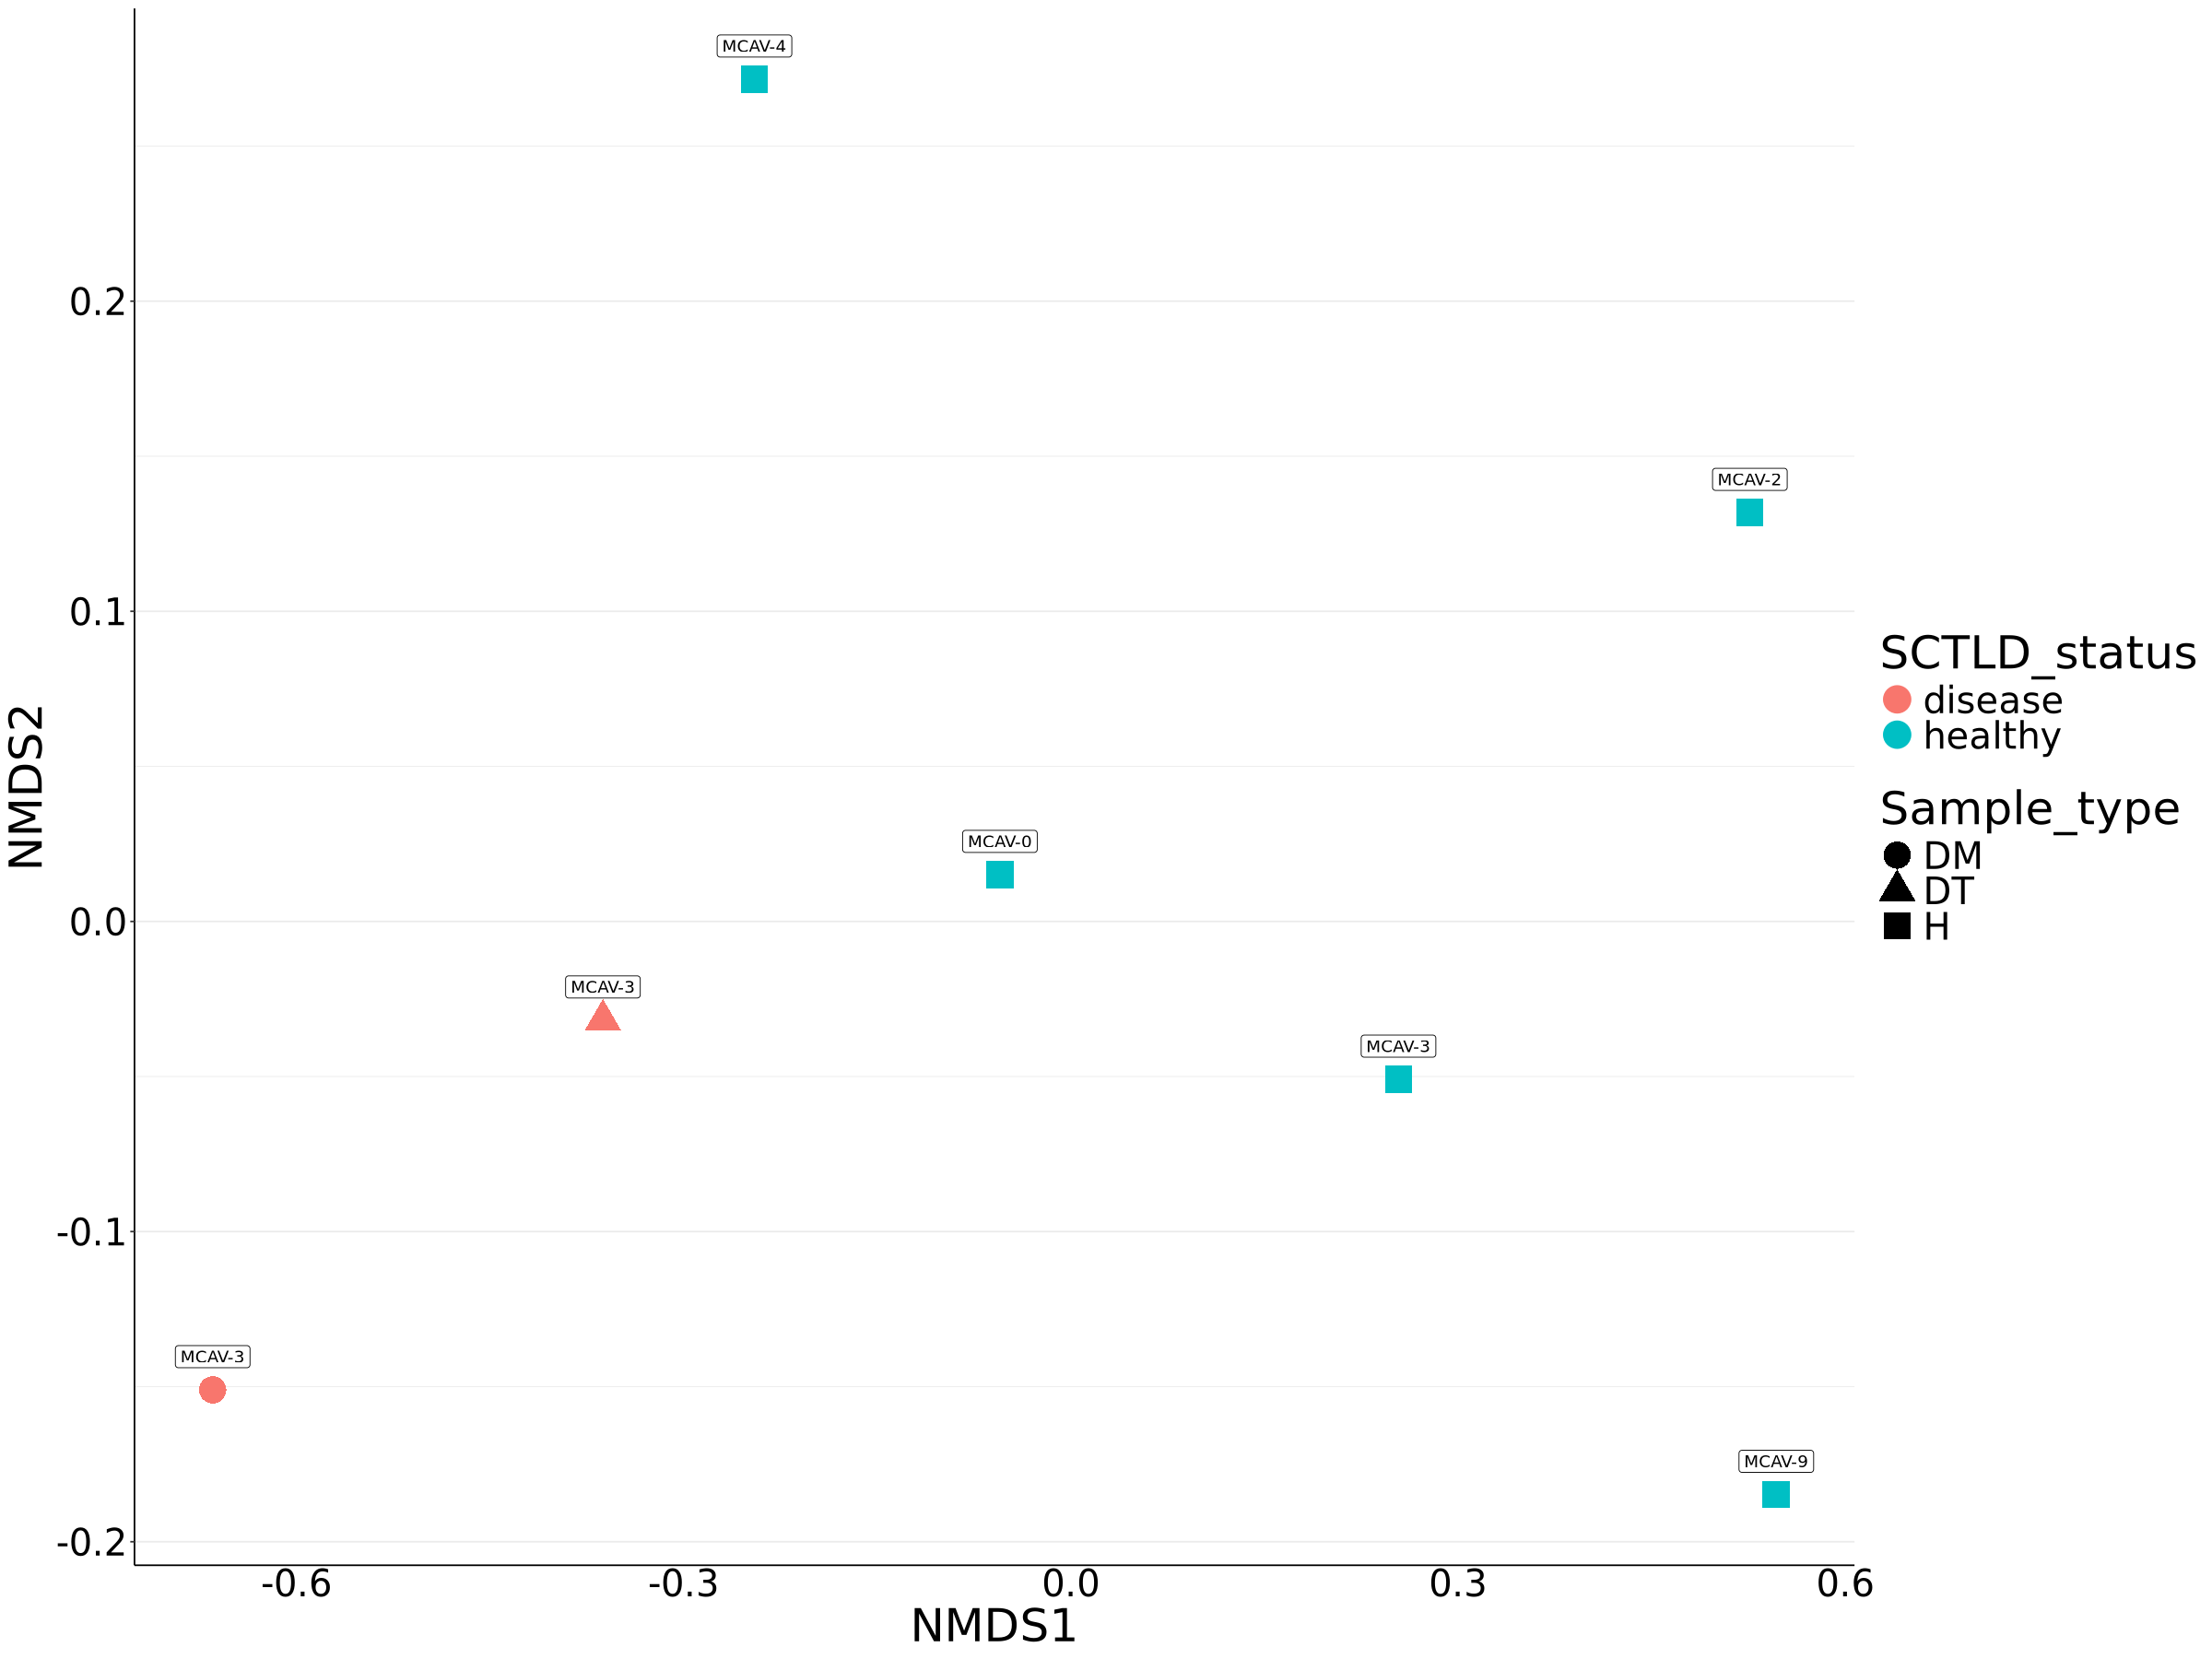

In [78]:
# visualize ordination plot
plot_ordination(DR_mcav, DR_mcav.ord, type="Samples", color="SCTLD_status", shape="Sample_type")+
geom_point(size=8)+
geom_label(aes(label = SAMP_M$Tag_num), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position="right", panel.border = element_blank(),
          panel.grid.major.x = element_blank(),
          panel.grid.minor.x = element_blank(),
          axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(color="black"),
          text = element_text(size=30))

#### DESeq2 on MCAV

In [51]:
#run DESeq2 on mcav
ds_mcav = phyloseq_to_deseq2(DR_mcav, ~ SCTLD_status)
ds_mcav = DESeq(ds_mcav, test="Wald", fitType="parametric")
res = results(ds_mcav, cooksCutoff = FALSE)
alpha = 0.0001
sigtab = res[which(res$padj < alpha), ]
sigtab_mcav = cbind(as(sigtab, "data.frame"), as(tax_table(DR_mcav)[rownames(sigtab), ], "matrix"))
res
head(sigtab_mcav)

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

-- note: fitType='parametric', but the dispersion trend was not well captured by the
   function: y = a/x + b, and a local regression fit was automatically substituted.
   specify fitType='local' or 'mean' to avoid this message next time.

final dispersion estimates

fitting model and testing



log2 fold change (MLE): SCTLD status healthy vs disease 
Wald test p-value: SCTLD status healthy vs disease 
DataFrame with 13490 rows and 6 columns
         baseMean log2FoldChange     lfcSE       stat    pvalue      padj
        <numeric>      <numeric> <numeric>  <numeric> <numeric> <numeric>
2066072  38001.36     -0.3678209  0.338236 -1.0874676  0.276830  0.715196
588596   20796.26      0.2245214  0.228493  0.9826201  0.325794  0.820176
562       7407.83     -0.0208798  0.287964 -0.0725083  0.942197  0.999989
5722      6066.81     -0.0208775  0.264777 -0.0788492  0.937153  0.999989
1280      5623.10     -0.0507102  0.201293 -0.2519224  0.801101  0.999989
...           ...            ...       ...        ...       ...       ...
2774776         0             NA        NA         NA        NA        NA
3378073         0             NA        NA         NA        NA        NA
2913501         0             NA        NA         NA        NA        NA
1967296         0             NA     

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.1468,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
654,812.1445,1.971204,0.3709804,5.313498,1.075408e-07,9.281703e-06,Aeromonas veronii
2034170,1011.5967,-28.465023,3.9245113,-7.253138,4.072239e-13,2.588093e-10,Trichoderma breve
584,421.4557,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2704462,516.0504,-13.364421,2.7121245,-4.927658,8.322127e-07,2.887537e-05,Paenibacillus lycopersici
28183,486.4441,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai


In [59]:
# sort by most significant 
sorted_sigtab <- sigtab_mcav %>%
  arrange(padj)
sorted_sigtab

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


In [60]:
#include just the top 20 for now
sorted_sigtab20 <- head(sorted_sigtab, 20)
sorted_sigtab20

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


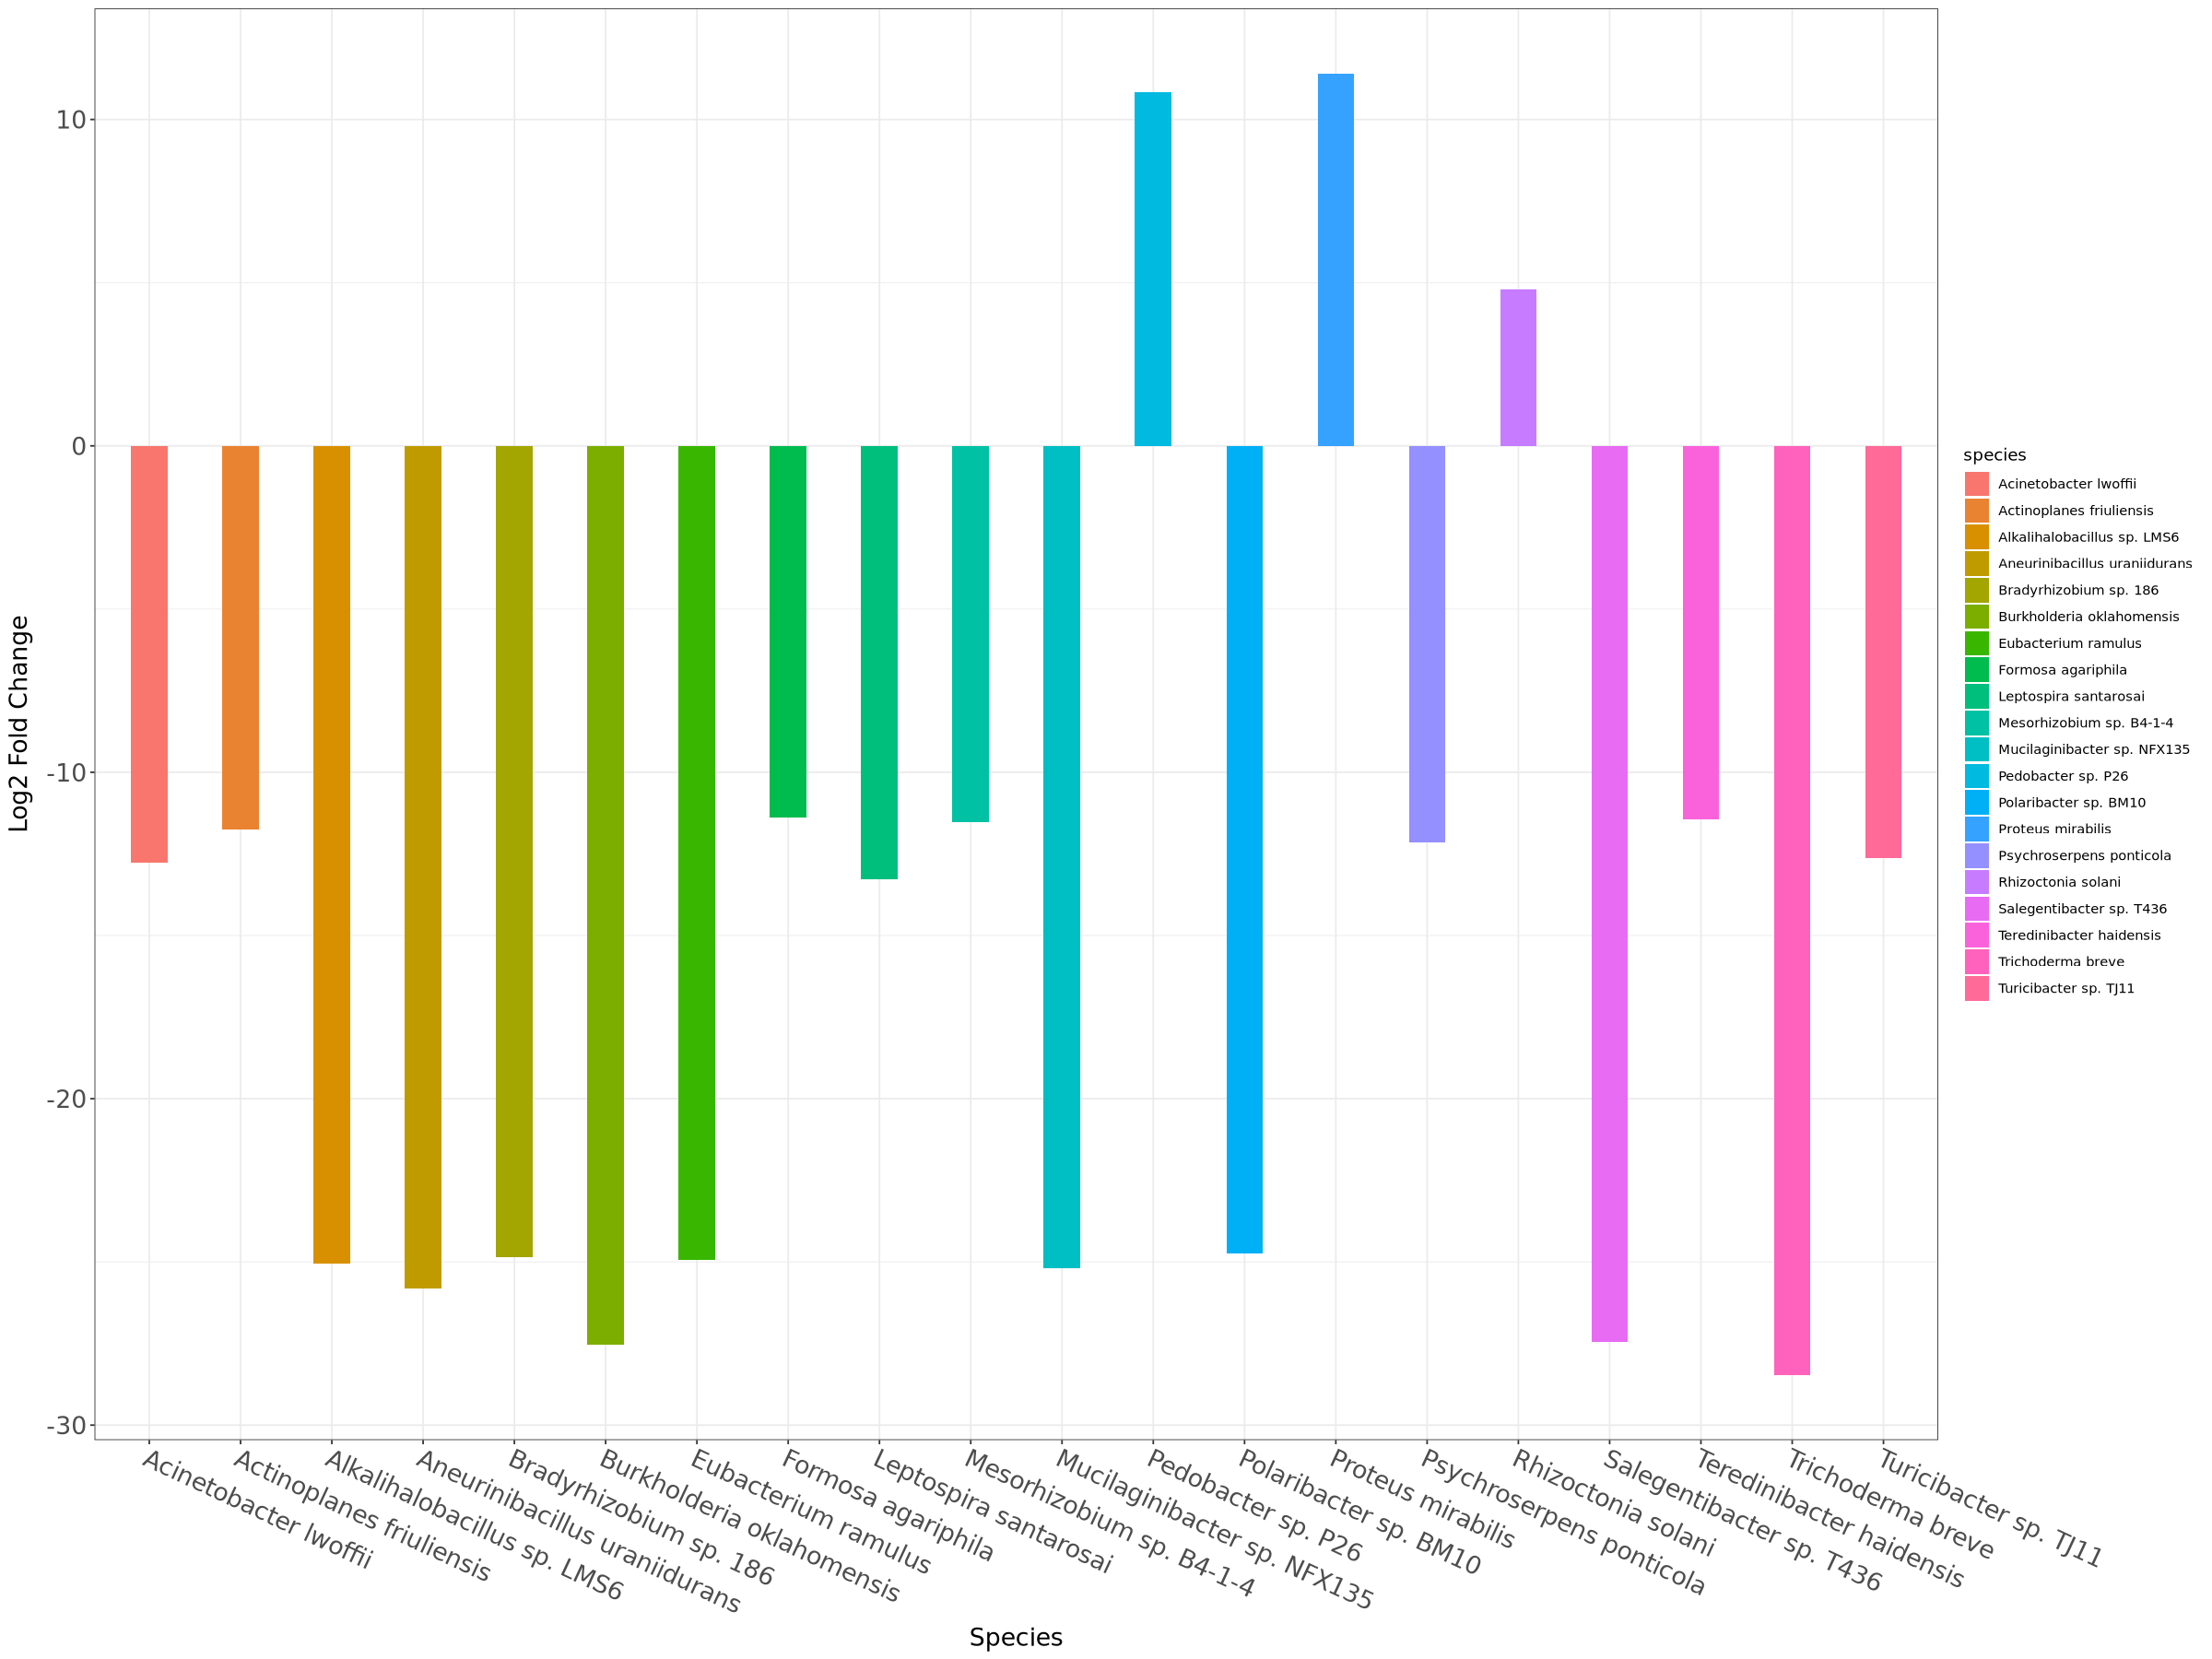

In [65]:
# plot significantly different OTUs top 20
ds_mcav <- ggplot(sorted_sigtab20, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_mcav

In [66]:
#include just the top 30 for now
sorted_sigtab30 <- head(sorted_sigtab, 30)
sorted_sigtab30

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
28183,486.44415,-13.279087,1.0085806,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.778664,1.0543501,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.625673,1.0692469,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.158139,1.2052878,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.754755,1.4070005,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.207641,3.2156462,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
2924034,68.41259,-25.064005,3.3762324,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6


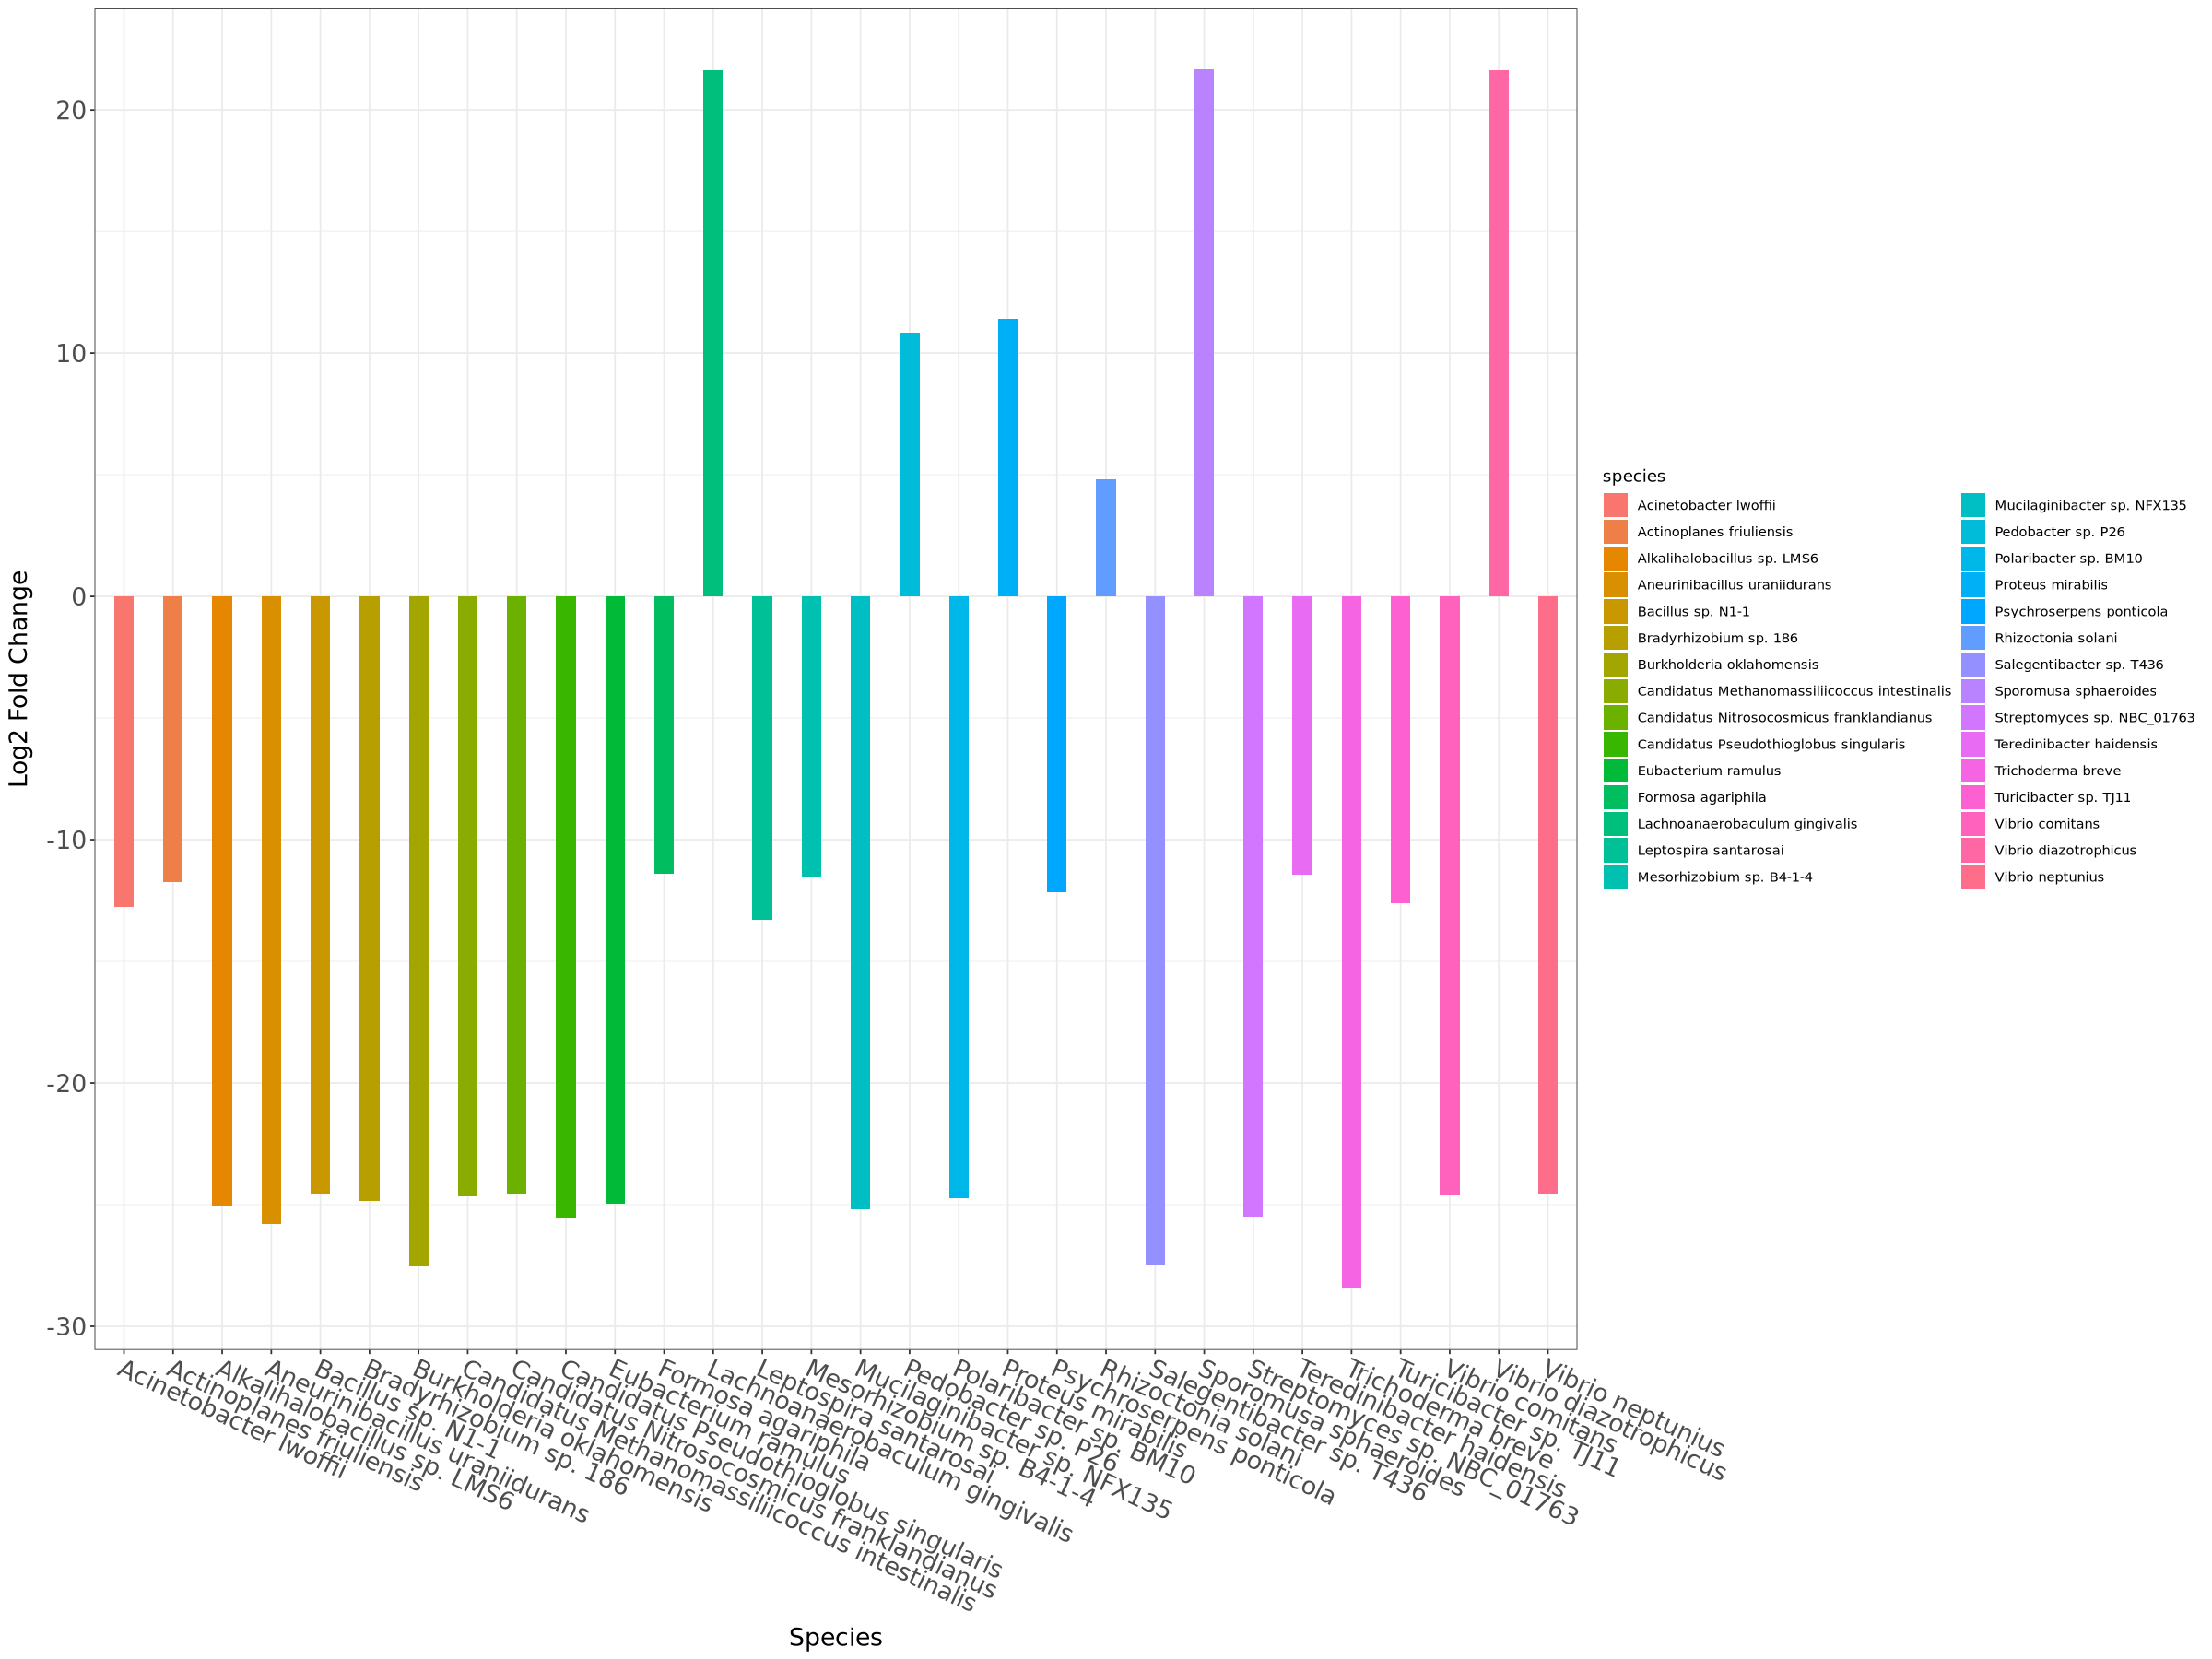

In [67]:
# plot significantly different OTUs top 30
ds_mcav_30 <- ggplot(sorted_sigtab30, aes(x = species, y = log2FoldChange, fill = species)) +
  geom_bar(stat = "identity", width = 0.4) +
theme_bw()+
  theme(
    axis.text.x = element_text(angle = -25, hjust = 0, vjust = 1, size = 16),  # Adjust text size
    axis.text.y = element_text(size = 16),  # Adjust y-axis text size
    axis.title.x = element_text(size = 16, margin = margin(t = 5)),  # Adjust x-axis title size and margin
    axis.title.y = element_text(size = 16, margin = margin(r = 10)),   # Adjust y-axis title size and add margin
  ) +
  labs(x = "Species", y = "Log2 Fold Change")

ds_mcav_30

In [71]:
# subset taxa that are assoc with healthy
healthy_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange>0,]
healthy_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
456999,2535.14683,4.802194,0.2416925,19.869022,7.545821e-88,5.275284e-84,Rhizoctonia solani
584,421.45569,11.408241,1.5273859,7.469128,8.072788e-14,7.054608e-11,Proteus mirabilis
3423956,282.19532,10.829433,1.5691897,6.901290,5.153243e-12,2.251645e-09,Pedobacter sp. P26
47679,73.53401,21.661404,3.5825332,6.046393,1.481244e-09,3.698350e-07,Sporomusa sphaeroides
685,72.68488,21.645287,3.6006770,6.011449,1.838721e-09,4.432586e-07,Vibrio diazotrophicus
2490855,71.97654,21.632330,3.6159531,5.982470,2.197791e-09,5.121587e-07,Lachnoanaerobaculum gingivalis
1211326,71.33096,21.615639,3.6245179,5.963728,2.465468e-09,5.560029e-07,Spirosoma aerolatum
3077937,69.40902,21.584884,3.6528147,5.909110,3.439612e-09,7.514477e-07,Rickettsiella endosymbiont of Rhagonycha lignosa
251701,69.13542,21.571363,3.6661287,5.883962,4.005592e-09,8.485786e-07,Pseudomonas syringae group genomosp. 3


In [70]:
# subset taxa that are assoc with disease
disease_mcav_otu<-sorted_sigtab[sorted_sigtab$log2FoldChange<0,]
disease_mcav_otu

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
28183,486.44415,-13.27909,1.008581,-13.166114,1.374945e-39,4.806119e-36,Leptospira santarosai
28090,343.86118,-12.77866,1.054350,-12.119944,8.281528e-34,1.929872e-30,Acinetobacter lwoffii
2806443,309.20479,-12.62567,1.069247,-11.808005,3.548810e-32,6.202433e-29,Turicibacter sp. TJ11
2932268,223.60674,-12.15814,1.205288,-10.087333,6.285390e-24,8.788232e-21,Psychroserpens ponticola
196914,169.08129,-11.75475,1.407000,-8.354478,6.572263e-17,7.657782e-14,Actinoplanes friuliensis
3402687,74.85588,-25.20764,3.215646,-7.839059,4.539346e-15,4.533510e-12,Mucilaginibacter sp. NFX135
2924034,68.41259,-25.06401,3.376232,-7.423661,1.139263e-13,8.849540e-11,Alkalihalobacillus sp. LMS6
2589888,143.80086,-11.52107,1.583213,-7.277017,3.412832e-13,2.385911e-10,Mesorhizobium sp. B4-1-4
2034170,1011.59670,-28.46502,3.924511,-7.253138,4.072239e-13,2.588093e-10,Trichoderma breve


In [72]:
endo_search <- sorted_sigtab[grepl("Endozoicomonas", sorted_sigtab$species), ]
endo_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2872754,13.69932,19.32814,4.038746,4.785678,1.704108e-06,3.599219e-05,Endozoicomonas sp. 4G


In [73]:
pseudo_search <- sorted_sigtab[grepl("Pseudoalteromonas", sorted_sigtab$species), ]
pseudo_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
28107,44.74674,20.97150,4.081214,5.138545,2.768736e-07,1.433795e-05,Pseudoalteromonas espejiana
28109,15.42464,19.49318,4.019456,4.849705,1.236450e-06,2.900678e-05,Pseudoalteromonas nigrifaciens
2907156,13.43929,18.70593,4.046588,4.622642,3.788827e-06,6.572627e-05,Pseudoalteromonas sp. N1230-9


In [75]:
vibrio_search <- sorted_sigtab[grepl("Vibrio", sorted_sigtab$species), ]
vibrio_search

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,species
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
413401,48.70370,-24.62073,3.802484,-6.474908,9.486944e-11,2.763468e-08,Vibrio comitans
170651,45.86107,-24.54374,3.827452,-6.412553,1.431029e-10,3.705306e-08,Vibrio neptunius
685,72.68488,21.64529,3.600677,6.011449,1.838721e-09,4.432586e-07,Vibrio diazotrophicus
2912314,51.46638,21.16644,4.081114,5.186436,2.143569e-07,1.198855e-05,Vibrio sp. JC009
3232307,44.74674,20.97150,4.081214,5.138545,2.768736e-07,1.433795e-05,Vibrio sp. HB236076
446372,35.43086,20.64311,4.081414,5.057833,4.240482e-07,1.989611e-05,Vibrio celticus
2819096,85.38113,20.35577,4.080851,4.988118,6.097027e-07,2.680774e-05,Vibrio sp. SCSIO 43135
3098914,25.19916,20.17505,4.081804,4.942680,7.705576e-07,2.887537e-05,Vibrio iocasae
664643,22.48011,20.01476,4.081968,4.903212,9.428204e-07,2.887537e-05,Vibrio plantisponsor


### Try running Lefse on this phyloseq object
https://rdrr.io/github/yiluheihei/microbiomeMarker/man/run_lefse.html

In [ ]:
#get other libraries loaded


#install this package
install.packages("remotes")
remotes::install_github("yiluheihei/microbiomeMarker")

maybe filter the asv table a bit more for taxa, to keep in mind:
https://david-barnett.github.io/microViz/reference/tax_filter.html